# Creating an End-To-End Dialogue System

In the last lab we want to create end-to-end dialogue systems, following on from the seq2seq MT labs you've done. Customer support apps and online helpdesks are among the places where conversational models can be used. Retrieval-based models, which produce predefined responses to questions of specific types, are often used to power these models. In this lab, the seq2seq model is used to build a generative model.

To begin, download the data and unzip them.

After that, let’s import some necessities.

In [1]:
!wget 'https://github.com/juntaoy/ECS7001_LAB_DATASETS/raw/refs/heads/main/CA_data.zip'
!unzip CA_data.zip -x __MACOSX/*

--2025-04-20 19:16:30--  https://github.com/juntaoy/ECS7001_LAB_DATASETS/raw/refs/heads/main/CA_data.zip
Resolving github.com (github.com)... 20.26.156.215
Connecting to github.com (github.com)|20.26.156.215|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/juntaoy/ECS7001_LAB_DATASETS/refs/heads/main/CA_data.zip [following]
--2025-04-20 19:16:31--  https://raw.githubusercontent.com/juntaoy/ECS7001_LAB_DATASETS/refs/heads/main/CA_data.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81802360 (78M) [application/zip]
Saving to: ‘CA_data.zip’

CA_data.zip         100%[===================>]  78.01M   326MB/s    in 0.2s    

2025-04-20 19:16:33 (326 MB/s) - ‘CA_data.zip’ saved [81802360/81802360]



In [1]:
pip install nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached regex-2024.11.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (40 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
Using cached regex-2024.11.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (792 kB)

[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import sys
import os
import random
import string
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu
np.random.seed(1)
random.seed(1)

# The Cornell Movie-Dialogs Corpus

The next move is to reformat our data file and load the data into functional structures.

The Cornell Movie-Dialogs Corpus contains 220,579 conversational exchanges between 10,292 pairs of movie characters, 9,035 characters from 617 movies, and 304,713 total utterances. This dataset is large with a wide variety of language formality, time periods, and other variables. Our hope is that this variety will make our model responsive to a wide range of queries.

In [3]:
#Loading the data
lines = open('movie_lines.txt', encoding='utf-8', errors='ignore').read().split('\n')
#lines = open('movie-corpus/utterances.jsonl', encoding='utf-8', errors='ignore').read().split('\n')
conv_lines = open('movie_conversations.txt', encoding='utf-8', errors='ignore').read().split('\n') # index of related lines

# Create a dictionary to map each id with its line
id2line = {}
for line in lines:
    _line = line.split(' +++$+++ ')
    if len(_line) == 5:
        id2line[_line[0]] = _line[4]

# Create a list of all of the ids.
convs = [ ]
for line in conv_lines[:-1]:
    _line = line.split(' +++$+++ ')[-1][1:-1].replace("'","").replace(" ","")
    convs.append(_line.split(','))

# Sort the sentences into questions (inputs) and answers (targets)
pairs = []
for conv in convs:
    for i in range(len(conv)-1):
        pairs.append([id2line[conv[i]],id2line[conv[i+1]]])

limit = 0
for i in range(limit, limit+5):
    print(pairs[i][0])
    print(pairs[i][1])
    print()

len(pairs)

Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.
Well, I thought we'd start with pronunciation, if that's okay with you.

Well, I thought we'd start with pronunciation, if that's okay with you.
Not the hacking and gagging and spitting part.  Please.

Not the hacking and gagging and spitting part.  Please.
Okay... then how 'bout we try out some French cuisine.  Saturday?  Night?

You're asking me out.  That's so cute. What's your name again?
Forget it.

No, no, it's my fault -- we didn't have a proper introduction ---
Cameron.



221616

We'll format data file with a question sentence and an answer sentence pair on each line for convenience.  Before we are ready to use this data, we must perform some preprocessing.


In [4]:
def preprocess(pairs):
    p = pairs.copy()

    for i in p:
        for j in range(0,2):
            i[j] = i[j].lower()
            i[j] = re.sub(r"there's", "there is", i[j])
            i[j] = re.sub(r"i'm", "i am", i[j])
            i[j] = re.sub(r"he's", "he is", i[j])
            i[j] = re.sub(r"she's", "she is", i[j])
            i[j] = re.sub(r"it's", "it is", i[j])
            i[j] = re.sub(r"that's", "that is", i[j])
            i[j] = re.sub(r"what's", "that is", i[j])
            i[j] = re.sub(r"where's", "where is", i[j])
            i[j] = re.sub(r"how's", "how is", i[j])
            i[j] = re.sub(r"\'ll", " will", i[j])
            i[j] = re.sub(r"\'ve", " have", i[j])
            i[j] = re.sub(r"\'re", " are", i[j])
            i[j] = re.sub(r"\'d", " would", i[j])
            i[j] = re.sub(r"\'re", " are", i[j])
            i[j] = re.sub(r"won't", "will not", i[j])
            i[j] = re.sub(r"can't", "cannot", i[j])
            i[j] = re.sub(r"n't", " not", i[j])
            i[j] = re.sub(r"n'", "ng", i[j])
            i[j] = re.sub(r"'bout", "about", i[j])
            i[j] = re.sub(r"'til", "until", i[j])
            i[j] = re.sub(r"[-()\"#/@;:<>{}`+=~|.!?,]", "", i[j])
            i[j] = i[j].strip()
    return p

replaced_pairs = preprocess(pairs)
def clean_data(pairs):
    p = pairs.copy()
    # prepare translation table
    table = str.maketrans('', '', string.punctuation)
    for i in p:
        # tokenize
        i[0], i[1] = i[0].split(), i[1].split()
        # convert to lower case
        i[0], i[1] = [word.lower() for word in i[0]], [word.lower() for word in i[1]]
        # remove punctuations
        i[0], i[1] = [w.translate(table) for w in i[0]], [w.translate(table) for w in i[1]]
        # remove numbers
        i[0], i[1] = [word for word in i[0] if word.isalpha()], [word for word in i[1] if word.isalpha()]
        # store as string
        i[0], i[1] =  ' '.join(i[0]), ' '.join(i[1])

    return p

clean_pairs = clean_data(replaced_pairs)
clean_pairs[:5]

[['can we make this quick roxanne korrine and andrew barrett are having an incredibly horrendous public break up on the quad again',
  'well i thought we would start with pronunciation if that is okay with you'],
 ['well i thought we would start with pronunciation if that is okay with you',
  'not the hacking and gagging and spitting part please'],
 ['not the hacking and gagging and spitting part please',
  'okay then how about we try out some french cuisine saturday night'],
 ['you are asking me out that is so cute that is your name again',
  'forget it'],
 ['no no it is my fault we did not have a proper introduction', 'cameron']]


The parsing of the raw movie lines.txt data file is made simpler with the following functions. We add the start and end tokens to our sentences. We also need to find the maximum length.



In [5]:
# adding the start and end tokens to our utterances
start_token = '<startseq>'
end_token = '<endseq>'

def add_end_start_tokens(pairs):
    p = pairs.copy()
    for i in p:
        i[0] = start_token + ' '  + i[0] + ' ' + end_token
        i[1] = start_token + ' '  + i[1] + ' ' + end_token
    return p

tokenized_pairs = add_end_start_tokens(clean_pairs)
tokenized_pairs[:5]

# finding the maximum length for questions and answers
# we caculate the max length that covers 80% of the data
def max_length(pairs,prct):
    # Create a list of all the utterances
    questions = []
    answers = []
    for i in pairs:
        questions.append(i[0])
        answers.append(i[1])

    length_questions = list(len(d.split()) for d in questions)
    length_answers = list(len(d.split()) for d in answers)

    return int(np.percentile(length_questions, prct)),int(np.percentile(length_answers, prct))

max_len_q,max_len_a = max_length(tokenized_pairs,80)

print('max-len of questions for training: ', max_len_q)
print('max-len of answers for training: ', max_len_a)

max-len of questions for training:  18
max-len of answers for training:  18


The next step is to build a vocabulary and save query/response pairs.
It's worth noting that we're dealing with word sequences that don't have an implicit mapping to a discrete numerical space. As a result, we must build one by assigning an index value to each unique word in our dataset.

We are going to create our vocabulary. Trimming rarely used words from our vocabulary is another strategy for achieving faster convergence during preparation. The complexity of the function that the model must learn to approximate will be lowered as the feature space is reduced.

In [6]:
# Remove questions and answers that are shorter than 2 words and longer than maxlen.
min_line_len = 2 # two words are for tokens

def set_length(tokenized_pairs):
    pairs_final = []
    for p in tokenized_pairs:
        if (
            len(p[0].split())>=min_line_len and len(p[1].split())>=min_line_len
           and len(p[0].split())<=max_len_q and len(p[1].split())<=max_len_a):

            pairs_final.append(p)

    return pairs_final

pairs_final = set_length(tokenized_pairs)
len(pairs_final)

# making a vocabulary of the words that occur more than word_count_threshold
def create_reoccurring_vocab(pairs, word_count_threshold = 5):
    p = pairs
    all_captions = []
    for i in p:
        for j in i:
            all_captions.append(j)

    # Consider only words which occur at least 10 times in the corpus
    word_counts = {}
    nsents = 0
    for sent in all_captions:
        nsents += 1
        for w in sent.split(' '):
            word_counts[w] = word_counts.get(w, 0) + 1

    vocab = [w for w in word_counts if word_counts[w] >= word_count_threshold]
    vocab = list(set(vocab))
    print('Short vocab size: %d ' % len(vocab))
    return vocab

# each word in the vocabulary must be used in the data at least 20 times
new_vocab = create_reoccurring_vocab(pairs_final, word_count_threshold = 4)
for v in new_vocab:
    if len(v) == 1 and v!='a' and v!='i':
        new_vocab.remove(v)

new_vocab = sorted(new_vocab)[1:]
new_vocab[:5]

Short vocab size: 14524 


['<endseq>', '<startseq>', 'a', 'aa', 'aaaah']

In [7]:
vocab_len = len(new_vocab) + 1 # since index 0 is used as padding, we have to increase the vocab size
vocab_len

14500

We are going to create a dataset of pairs without the trimmed words.

In [8]:
def progressBar(value, endvalue, bar_length=20, job=''):

    percent = float(value) / endvalue
    arrow = '-' * int(round(percent * bar_length)-1) + '>'
    spaces = ' ' * (bar_length - len(arrow))

    sys.stdout.write("\r{0} : [{1}] {2}%".format(job,arrow + spaces, int(round(percent * 100))))
    sys.stdout.flush()

In [9]:
# keeping the pairs with words in the vocab
# The code is for your refernce, it take too long (12m) so we provide you the file already processed
def trimRareWords(voc, pairs):
    # Filtering out the pairs with the oov words
    keep_pairs = []
    i=0
    for pair in pairs:
        i+=1
        progressBar(value=i,endvalue=len(pairs))
        input_sentence = pair[0]
        output_sentence = pair[1]
        keep_input = True
        keep_output = True
        #  input sentence
        for word in input_sentence.split(' '):
            if word not in voc:
                keep_input = False
                break
        #  output sentence
        for word in output_sentence.split(' '):
            if word not in voc:
                keep_output = False
                break

        if keep_input and keep_output:
            keep_pairs.append(pair)

    print("\nTrimmed from {} pairs to {}".format(len(pairs), len(keep_pairs)))
    return keep_pairs


# # Trim voc and pairs
# pairs_final = trimRareWords(new_vocab, pairs_final)
# with open ('final_pairs_v21.pkl','wb') as f:
#     pairs_final = pickle.dump(pairs_final,f)

with open ('final_pairs_v21.pkl','rb') as f:
    pairs_final = pickle.load(f)

pairs_final_train = pairs_final
len(pairs_final_train)

114938

# Embedding layer

Our models will eventually expect numerical tensors as inputs, despite the fact that we put a lot of effort into preparing and massaging our data into a nice vocabulary object and list of sentence pairs. The Embedding layer can be used to load a pre-trained word embedding model. We are going to use GloVe embeddings. You can download GloVe and we can seed the Keras Embedding layer with weights from the pre-trained embedding for the words in your dataset.

To download GloVe embeddings and uzip them use the following commands:

Now let's load them in the embedding layer

In [10]:
!pip install tokenizers

  Using cached tokenizers-0.21.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached huggingface_hub-0.30.2-py3-none-any.whl.metadata (13 kB)
Using cached tokenizers-0.21.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.0 MB)
Using cached huggingface_hub-0.30.2-py3-none-any.whl (481 kB)

[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
pip install transformers

  Using cached transformers-4.51.3-py3-none-any.whl.metadata (38 kB)
  Using cached safetensors-0.5.3-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.8 kB)
Using cached transformers-4.51.3-py3-none-any.whl (10.4 MB)
Using cached safetensors-0.5.3-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (471 kB)

[notice] A new release of pip is available: 24.1.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import torch.nn as nn
import torch
from transformers import PreTrainedTokenizerFast
from tokenizers import Tokenizer, models, pre_tokenizers

torch.manual_seed(1)

test = False
GRU_units = 50
batch_size = 512
emb_dim = 50
init_lr = 0.001

pad_token = 'pad0'
vocab_with_pad = [pad_token] + new_vocab
wordtoix = {word: idx for idx, word in enumerate(vocab_with_pad)}
ixtoword = {idx: word for word, idx in wordtoix.items()}
tokenizer = Tokenizer(models.WordLevel(vocab=wordtoix, unk_token='[UNK]'))
# tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
# hf_tokenizer = PreTrainedTokenizerFast(tokenizer_object=tokenizer, pad_token=pad_token)

def make_embedding_layer(embedding_dim=50, glove=True, glove_weight_path="glove.6B.50d.txt"):
    """
    Creates a PyTorch nn.Embedding layer with either:
    (1) GloVe pre-trained weights if glove=True, OR
    (2) A zero-initialized matrix if glove=False.
    """

    if not glove:
        print('Just a zero matrix loaded')
        embedding_matrix = np.zeros((vocab_len, embedding_dim), dtype=np.float32)
    else:
        print('Loading glove...')
        embeddings_index = {}
        # Make sure you have 'glove.6B.50d.txt' in the correct path
        # or adjust the path as needed.
        with open(glove_weight_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
        print("GloVe", embedding_dim, "loaded!")

        # Initialize an empty embedding matrix
        embedding_matrix = np.zeros((vocab_len, embedding_dim), dtype=np.float32)

        # Fill the embedding matrix with GloVe values
        for word, i in wordtoix.items():
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector

    embedding_layer = nn.Embedding(
        num_embeddings=vocab_len,
        embedding_dim=embedding_dim,
        padding_idx=0
    )

    # Convert the numpy embedding matrix to a PyTorch tensor
    with torch.no_grad():
        embedding_layer.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))

    # If you want the embedding to remain un-trainable, set requires_grad = False:
    embedding_layer.weight.requires_grad = False

    return embedding_layer



In [13]:
# Create the embedding layer
embeddings = make_embedding_layer(embedding_dim=emb_dim)

Loading glove...
GloVe 50 loaded!


# Seq2Seq Model



A sequence-to-sequence (seq2seq) model is at the core of our model. The purpose of a seq2seq model is to use a fixed-sized sequence as an input and generate a variable-length sequence as an output.

[Sutskever et al.](https://arxiv.org/abs/1409.3215) found that we can do this task by combining two different recurrent neural nets. One  RNN serves as an encoder, converting a variable-length input sequence to a fixed-length context vector. This context vector (the RNN's final hidden layer) contain semantic knowledge about the query sentence that the system receives.



# Encoder

The encoder RNN iterates through the input sentence one token at a time, producing an "output" vector and a "hidden state" vector at each time step.  The output vector is recorded while the hidden state vector is transferred to the next time step. The encoder converts the context it observed at each point in the sequence into a set of points in a high-dimensional space, which the decoder can use to produce a meaningful output for the task at hand.

A multi-layered Gated Recurrent Unit, created by [Cho et al.](https://arxiv.org/pdf/1406.1078v3.pdf), is at the centre of our encoder. We'll use a bidirectional version of the GRU, which effectively means there are two separate RNNs: one fed the input sequence in regular sequential order and the other fed the input sequence in reverse order. At each time point, the outputs of each network are added together.

In [68]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_size=batch_size, dropout=0.2):
        """
        Initializes the Encoder.

        Args:
            vocab_size (int): Size of the vocabulary.
            embedding_dim (int): Dimension of the embedding vectors.
            enc_units (int): Number of units in the GRU.
            batch_size (int): Size of each batch.
            embeddings (torch.Tensor, optional): Pre-trained embedding weights. Defaults to None.
            dropout (float, optional): Dropout probability. Defaults to 0.2.
        """
        super(Encoder, self).__init__()
        self.batch_size = batch_size
        self.enc_units = enc_units

        """
        Task 1: Implementing the encoder

        Begin
        """
        self.embeddings = embeddings  # embedd layer
        
        self.dropout = nn.Dropout(dropout) # apply dropout

        # Bidirectnl GRU 
        # input_size: embedding_dim, 
        # hidden_size: enc_units per direction
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=enc_units,
            batch_first=True,
            bidirectional=True
        )

        """
        End Task 1
        """

    def forward(self, x, hidden=None):
        """
        Forward pass of the encoder.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, seq_length).
            hidden (torch.Tensor, optional): Initial hidden state. Defaults to None.

        Returns:
            Tuple[torch.Tensor, torch.Tensor, torch.Tensor]: Output sequences, forward hidden state, backward hidden state.
        """
        # x: [batch_size, seq_length]
        x = self.embeddings(x)  # [batch_size, seq_length, embedding_dim]
        x = self.dropout(x)

        # Pass through the GRU
        # If hidden is not provided, it defaults to zeros
        output, hidden = self.gru(x, hidden)
        # output: [batch_size, seq_length, enc_units * 2]
        # hidden: [num_layers * num_directions, batch_size, enc_units]

        # Separate the hidden states for forward and backward directions
        # Since it's bidirectional and num_layers=1, hidden has shape (2, batch_size, enc_units)
        hidden_f = hidden[0]  # Forward hidden state: [batch_size, enc_units]
        hidden_b = hidden[1]  # Backward hidden state: [batch_size, enc_units]

        return output, hidden_f, hidden_b

    def initialize_hidden_state(self):
            """
            Initializes the hidden state to zeros.

            Returns:
                torch.Tensor: Initialized hidden state of shape (num_directions, batch_size, enc_units).
            """
            # Number of directions is 2 for bidirectional GRU
            return torch.zeros(2, self.batch_size, self.enc_units)


In [69]:
encoder = Encoder(vocab_len, 50, GRU_units)

In [70]:
print(encoder)

Encoder(
  (embeddings): Embedding(14500, 50, padding_idx=0)
  (dropout): Dropout(p=0.2, inplace=False)
  (gru): GRU(50, 50, batch_first=True, bidirectional=True)
)


# Decoder

The response utterance is produced token by token by the decoder RNN. It generates the next word in the sequence using the encoder's context vectors and internal hidden states. It keeps producing words until it reaches the end of the sentence, which is represented by an end_token. A common issue with a standard seq2seq decoder is that relying solely on the context vector to encode the meaning of the complete input sequence would almost certainly result in information loss. This is particularly true when dealing with long input sequences, severely restricting our decoder's capabilities.

[Bahdanau et al.](https://arxiv.org/abs/1409.0473) devised an "attention mechanism" that allows the decoder to focus on specific parts of the input sequence rather than using the whole set context at each step to deal with information loss. Attention is determined using the encoder's outputs and the decoder's current hidden state. Since the output attention weights have the same shape as the input sequence, we may multiply them by the encoder outputs to get a weighted amount that shows which sections of the encoder output to focus on.

In [71]:
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(units, units)
        self.W2 = nn.Linear(units, units)
        self.V = nn.Linear(units, 1)
        self.units = units

    def forward(self, query, values):
        """
        Args:
            query: Decoder hidden state at current time step. Shape: (batch_size, hidden_size)
            values: Encoder outputs. Shape: (batch_size, max_length, hidden_size)

        Returns:
            context_vector: Weighted sum of encoder outputs. Shape: (batch_size, hidden_size)
            attention_weights: Attention scores. Shape: (batch_size, max_length, 1)
        """
        # Add a time axis to the query to enable broadcasting
        # Shape: (batch_size, 1, hidden_size)
        query_with_time_axis = query.unsqueeze(1)

        # Calculate the score
        # Shape before self.V: (batch_size, max_length, units)
        score = self.V(torch.tanh(
            self.W1(query_with_time_axis) + self.W2(values)
        ))

        # Apply softmax to get attention weights
        # Shape: (batch_size, max_length, 1)
        attention_weights = F.softmax(score, dim=1)

        # Compute the context vector as the weighted sum of encoder outputs
        # Shape after sum: (batch_size, hidden_size)
        context_vector = attention_weights * values
        context_vector = torch.sum(context_vector, dim=1)

        return context_vector, attention_weights

In [72]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_size=batch_size):
        super(Decoder, self).__init__()
        self.batch_size = batch_size
        self.embedding = embeddings
        self.units = 2 * dec_units  # Assuming bidirectional encoder
        self.fc = nn.Linear(self.units, vocab_len)

        """
        Task 2: Implementing the decoder with attention

        Begin
        """
        dropout_prob = 0.2
        # Attention mechanism
        self.attention = BahdanauAttention(self.units)
        # Dropout for embedding
        self.embedding_dropout = nn.Dropout(dropout_prob)
        # 1st gru 
        # input is [context_vector + embedding]
        self.decoder_gru_l1 = nn.GRU(
            input_size=embedding_dim + self.units,
            hidden_size=self.units,
            batch_first=True
        )
        # Dropout between gru layers
        self.dropout = nn.Dropout(dropout_prob)
        
        # 2nd gru input is --> output from 1st GRU
        self.decoder_gru_l2 = nn.GRU(
            input_size=self.units,
            hidden_size=self.units,
            batch_first=True
        )

        """
        End Task 2
        """


    def forward(self, x, hidden, enc_output):
        """
        Args:
            x: Input token indices. Shape: (batch_size, 1)
            hidden: Previous hidden state. Shape: (batch_size, hidden_size)
            enc_output: Encoder outputs. Shape: (batch_size, max_length, hidden_size)

        Returns:
            output: Predictions for the next token. Shape: (batch_size, vocab_len)
            state: Current hidden state. Shape: (batch_size, hidden_size)
            attention_weights: Attention scores. Shape: (batch_size, max_length, 1)
        """
        # Compute attention weights and context vector
        context_vector, attention_weights = self.attention(hidden, enc_output)

        # Embed the input token
        # Shape: (batch_size, 1, embedding_dim)
        x = self.embedding_dropout(self.embedding(x))

        # Concatenate context vector and embedded input
        # Shape: (batch_size, 1, embedding_dim + hidden_size)
        x = torch.cat([context_vector.unsqueeze(1), x], dim=-1)

        # Pass through the first GRU layer
        # GRU expects input of shape (batch_size, seq_length, input_size)
        # Output shape: (batch_size, 1, units)
        x, _ = self.decoder_gru_l1(x)

        # Apply dropout
        x = self.dropout(x)

        # Pass through the second GRU layer
        # Output shape: (batch_size, 1, units)
        x, state = self.decoder_gru_l2(x)

        # Reshape to (batch_size, units)
        x = x.squeeze(1)

        # Pass through the fully connected layer
        # Shape: (batch_size, vocab_len)
        x = self.fc(x)

        return x, state, attention_weights

In [73]:
decoder = Decoder(vocab_len, 50, GRU_units)

In [74]:
print(decoder)

Decoder(
  (embedding): Embedding(14500, 50, padding_idx=0)
  (fc): Linear(in_features=100, out_features=14500, bias=True)
  (attention): BahdanauAttention(
    (W1): Linear(in_features=100, out_features=100, bias=True)
    (W2): Linear(in_features=100, out_features=100, bias=True)
    (V): Linear(in_features=100, out_features=1, bias=True)
  )
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (decoder_gru_l1): GRU(150, 100, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (decoder_gru_l2): GRU(100, 100, batch_first=True)
)


# Evaluation

We can now write functions to evaluate a string input sentence now that we've established our decoding process. The evaluate function is in charge of the low-level handling of the input sentence. The sentence is first formatted as an input batch of word indexes. To prepare the tensor for our models, we convert the words of the sentence to their corresponding indexes and transpose the dimensions. Our system's user interface is called answer. Our text is normalised in the same way that our training data is, and then fed into the evaluate function to generate a decoded output sentence and attention weights.

In [19]:
import unicodedata
import matplotlib.ticker as ticker

def pad_sequences(sequences, maxlen):
    return [seq[:maxlen] + [0] * (maxlen - len(seq)) for seq in sequences]

# function for plotting the attention weights
def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
      if unicodedata.category(c) != 'Mn')

def evaluate(sentence, device):
    encoder.to(device)
    decoder.to(device)

    attention_plot = np.zeros((max_len_a, max_len_q))

    sentence = unicode_to_ascii(sentence.lower())
    inputs = [wordtoix[i] for i in sentence.split(' ')]
    inputs = [wordtoix[start_token]]+inputs+[wordtoix[end_token]]
    inputs = pad_sequences([inputs],maxlen=max_len_q)

    inputs = torch.Tensor(inputs).to(torch.int32).to(device)

    result = ''

    hidden = torch.zeros(2, inputs.shape[0], GRU_units)
    enc_out, enc_hidden_f, enc_hidden_b = encoder(inputs, hidden)

    dec_hidden = torch.cat((enc_hidden_f, enc_hidden_b), dim=-1)  # Shape: (1, batch, hidden_size * 2)
    dec_input = torch.tensor([[wordtoix[start_token]]], device=device)  # Shape: (1, 1)

    for t in range(max_len_a):
        predictions, dec_hidden, attention_weights = decoder(dec_input,
                                                             dec_hidden,
                                                             enc_out)
        dec_hidden = dec_hidden[0]
        attention_weights = attention_weights.squeeze(0).view(-1).detach().cpu().numpy()

        attention_plot[t] = attention_weights
        predicted_id =  predictions.argmax(dim=1).item()

        if ixtoword[predicted_id] == end_token:
            return result, sentence, attention_plot

        result += ixtoword[predicted_id] + ' '
        # the predicted ID is fed back into the model
        dec_input = torch.tensor([[predicted_id]], device=device)

    return result, sentence, attention_plot

def answer(sentence, training=False, device="cpu"):
    result, sentence, attention_plot = evaluate(sentence,device)

    if training:
        return result

    print('Input: %s' % (sentence))
    print('Predicted answer: {}'.format(result))
    attention_plot = attention_plot[1:len(result.split(' ')), :len(sentence.split(' '))]
    plot_attention(attention_plot, sentence.split(' '), result.split(' ')[:-1])

# Greedy decoding

Greedy decoding is a decoding method in which we simply choose the highest softmax value word from decoder output for each time stage. On a single time-step stage, this decoding method is optimal. It is common in neural machine translation systems to use a beam-search to sample the probabilities for the words in the sequence output by the model.

The wider the beam width, the more exhaustive the search, and, it is believed, the better the results.

The results showed that a modest beam-width of 3-5 performed the best, which could be improved only very slightly through the use of length penalties.

In [20]:
def beam_search(sentence, k=5, maxsample=max_len_a, use_unk=False, oov=None, eos=end_token, device="cpu"):


    dead_k = 0 # samples that reached eos
    dead_samples = []
    dead_scores = []
    live_k = 1 # samples that did not yet reached eos
    live_samples = [[wordtoix[start_token]]]
    live_scores = [0]

    sentence = unicode_to_ascii(sentence.lower())
    inputs = [wordtoix[i] for i in sentence.split(' ')]
    inputs = [wordtoix[start_token]]+inputs+[wordtoix[end_token]]
    inputs = pad_sequences([inputs],maxlen=max_len_q)

    inputs = torch.Tensor(inputs).to(torch.int32).to(device)

    hidden = torch.zeros(2, inputs.shape[0], GRU_units)
    enc_out, enc_hidden_f, enc_hidden_b = encoder(inputs, hidden)   # (1, max_len_q, 2*enc_hidden_dim), (1, enc_hidden_dim), (1, enc_hidden_dim)

    # Concatenate forward and backward hidden states for the decoder
    dec_hidden = torch.cat((enc_hidden_f, enc_hidden_b), dim=-1)  # shape (1, batch_size, 2*GRU_units)
    dec_input = torch.tensor([[wordtoix[start_token]]], device=device)


    while live_k and dead_k < k:
        # for every possible live sample calc prob for every possible label
        predictions, dec_hidden, _ = decoder(dec_input,dec_hidden,enc_out)
        dec_hidden = dec_hidden[0]

        predictions = F.softmax(predictions,-1)
        probs = predictions[0].detach().numpy()

        # total score for every sample is sum of -log of word prb
        cand_scores = np.array(live_scores)[:,None] - np.log(probs)
        if not use_unk and oov is not None:
            cand_scores[:,oov] = 1e20
        cand_flat = cand_scores.flatten()

        # find the best (lowest) scores we have from all possible samples and new words
        ranks_flat = cand_flat.argsort()[:(k-dead_k)]
        live_scores = cand_flat[ranks_flat]

        # append the new words to their appropriate live sample
        voc_size = vocab_len
        live_samples = [live_samples[r//voc_size]+[r%voc_size] for r in ranks_flat]

        # live samples that should be dead are...
        zombie = [s[-1] == eos or len(s) >= maxsample for s in live_samples]

        # add zombies to the dead
        dead_samples += [s for s,z in zip(live_samples,zombie) if z]  # remove first label == empty
        dead_scores += [s for s,z in zip(live_scores,zombie) if z]
        dead_k = len(dead_samples)
        # remove zombies from the living
        live_samples = [s for s,z in zip(live_samples,zombie) if not z]
        live_scores = [s for s,z in zip(live_scores,zombie) if not z]
        live_k = len(live_samples)

    final_samples = dead_samples + live_samples
    final_scores = dead_scores + live_scores

    # cutting the strong where end_token is encounterd
    for i in range(len(final_scores)):
        final_scores[i] /= len(final_samples[i]) # normalizing the scores

    final_result =[]

    for i in range(len(final_scores)):
        final_result.append((final_scores[i],final_samples[i]))

    final_list_ix = max(final_result)[1]
    final_list_word = [ixtoword[f] for f in final_list_ix]
    final_sentence = ' '.join(final_list_word[1:])
    end_ix = final_sentence.find(end_token)
    return final_sentence[:end_ix]

# Training procedure

## Masked loss

We can't simply consider all elements of the tensor when evaluating loss because we're dealing with batches of padded sequences. Based on our decoder's output tensor, the target tensor, and a binary mask tensor describing the padding of the target tensor, we define a function to measure our loss.

In [21]:
loss_fn = nn.CrossEntropyLoss(ignore_index=0)

## Single training iteration

The algorithm for a single training iteration is contained in the train_step function (a single batch of inputs). To help with convergence, we'll use teacher forcing. This means that we use the current target word as the decoder's next input rather than the decoder's current guess in some probabilities. This technique serves as decoder training wheels, allowing for more effective training. However, since the decoder may not have had enough time to truly craft its own output sequences during training, teacher forcing can lead to model instability during inference.



In [22]:
import torch.optim as optim
encoder_optimizer = optim.Adam(encoder.parameters(), lr=init_lr)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=init_lr)

def train_step(
    inp,
    targ,
    enc_hidden,
    device
):
    """
    Equivalent PyTorch/HuggingFace-style training step for a seq2seq model
    with teacher forcing.
    """
    inp = inp.to(device)
    targ = targ.to(device)
    enc_hidden = enc_hidden.to(device)
    # Ensure we're in training mode
    encoder.train()
    decoder.train()
    encoder.to(device)
    decoder.to(device)

    # Clear the gradients
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    loss = 0.0

    # Forward pass through the encoder
    # (Returns enc_output, enc_hidden_f, enc_hidden_b, similar to your TF code)
    enc_output, enc_hidden_f, enc_hidden_b = encoder(inp, enc_hidden)

    # Concatenate the forward and backward encoder hidden states
    # (mimicking `Concatenate(axis=-1)([enc_hidden_f, enc_hidden_b])` in Keras)
    dec_hidden = torch.cat([enc_hidden_f, enc_hidden_b], dim=-1)

    # Initialize the decoder input with the start token (teacher forcing setup)
    batch_size = inp.size(0)
    device = inp.device
    dec_input = torch.tensor(
        [wordtoix[start_token]] * batch_size,
        dtype=torch.long,
        device=device
    ).unsqueeze(1)  # shape: (batch_size, 1)

    # Teacher forcing: feed the *target* back into the decoder at each step
    for t in range(1, targ.size(1)):
        # Forward pass through the decoder
        # returns (predictions, dec_hidden, <optional other outputs>)
        predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
        dec_hidden = dec_hidden[0]
        # Accumulate the loss at each time step
        # predictions shape example: (batch_size, vocab_size)
        # targ[:, t] shape: (batch_size,)
        step_loss = loss_fn(predictions, targ[:, t])
        loss += step_loss

        # The target word at timestep t becomes the input for the next step
        dec_input = targ[:, t].unsqueeze(1)

    # Compute average loss per sequence length
    batch_loss = loss / targ.size(1)

    if not torch.isnan(batch_loss):
      # Backpropagation
      batch_loss.backward()

      torch.nn.utils.clip_grad_norm_(encoder.parameters(), 5.0)
      torch.nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)



      # Update parameters
      encoder_optimizer.step()
      decoder_optimizer.step()

    return batch_loss.item()

In [23]:
history={'loss':[]}
smallest_loss = np.inf
best_ep = 1
EPOCHS = 100
enc_hidden = encoder.initialize_hidden_state()
steps_per_epoch = len(pairs_final_train)//batch_size # used for caculating number of batches
current_ep = 1

We are creating a test_bot to monitor our training in every time step.

In [24]:
def test_bot(k = 5, beam = False, device="cpu"):
    print('#'*20)
    q = 'Hello'
    print('Greedy| Q:',q,'  A:',answer(q, training=True))
    if beam:print('Beam ',k,'| ',q,'  A:',beam_search(q,k=k,device=device))
    print('%')
    q = 'How are you'
    print('Greedy| Q:',q,'?  A:',answer(q, training=True))
    if beam:print('Beam ',k,'| ',q,'?  A:',beam_search(q,k=k,device=device))
    print('%')

    q = 'What are you doing'
    print('Greedy| Q:',q,'?  A:',answer(q, training=True))
    if beam:print('Beam ',k,'| ',q,'?  A:',beam_search(q,k=k,device=device))
    print('%')
    q = 'What is your favorite restaurant'
    print('Greedy| Q:',q,'?  A:',answer(q, training=True))
    if beam:print('Beam ',k,'| ',q,'?  A:',beam_search(q,k=k,device=device))
    print('%')

    q = 'Do you want to go out'
    print('Greedy| Q:',q,'?  A:',answer(q, training=True))
    if beam:print('Beam ',k,'| ',q,'?  A:',beam_search(q,k=k,device=device))
    print('#'*20)

## Training iterations

It's finally time to link the entire training procedure to the data. Given the passed models, optimizers, data, and so on, the function is responsible for running n iterations of training. We've already done the heavy lifting with the train_step function, so this function is self-explanatory.

One thing to keep in mind is that when we save our model, the encoder and decoder parameters, the optimizer parameters, the loss, the iteration, and so on are all saved. This method of saving the model will give us the most flexibility with the checkpoint. We can use the model parameters to run inference after loading a checkpoint, or we can begin training where we left off.

Epoch 1 Batch 37 Loss: 5.4000
Epoch 1 Batch 74 Loss: 5.3019
Epoch 1 Batch 111 Loss: 4.9903
Epoch 1 Batch 148 Loss: 4.8980
Epoch 1 Batch 185 Loss: 5.0609
Epoch 1 Batch 222 Loss: 4.9700

*** Epoch 1 Loss 5.4453 ***

####################
Greedy| Q: Hello   A: 
Beam  5 |  Hello   A: 
%
Greedy| Q: How are you ?  A: 
Beam  5 |  How are you ?  A: 
%
Greedy| Q: What are you doing ?  A: 
Beam  5 |  What are you doing ?  A: 
%
Greedy| Q: What is your favorite restaurant ?  A: 
Beam  5 |  What is your favorite restaurant ?  A: 
%
Greedy| Q: Do you want to go out ?  A: 
Beam  5 |  Do you want to go out ?  A: 
####################
checkpoint saved!
Best epoch so far:  1
Time  19.038 sec

Epoch 2 Batch 37 Loss: 5.1433
Epoch 2 Batch 74 Loss: 4.8889
Epoch 2 Batch 111 Loss: 4.9306
Epoch 2 Batch 148 Loss: 4.9148
Epoch 2 Batch 185 Loss: 4.9461
Epoch 2 Batch 222 Loss: 5.0471

*** Epoch 2 Loss 5.0056 ***

####################
Greedy| Q: Hello   A: 
Beam  5 |  Hello   A: 
%
Greedy| Q: How are you ?  A: 
Bea

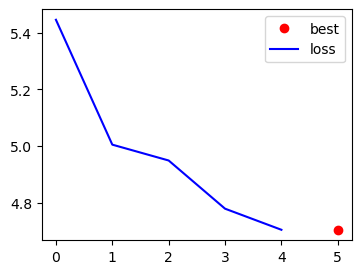

Best epoch so far:  5
Time  19.064 sec

Epoch 6 Batch 37 Loss: 4.6979
Epoch 6 Batch 74 Loss: 4.5303
Epoch 6 Batch 111 Loss: 4.5112
Epoch 6 Batch 148 Loss: 4.4889
Epoch 6 Batch 185 Loss: 4.5313
Epoch 6 Batch 222 Loss: 4.6320

*** Epoch 6 Loss 4.5956 ***

####################
Greedy| Q: Hello   A: i do not not 
Beam  5 |  Hello   A: what 
%
Greedy| Q: How are you ?  A: i am 
Beam  5 |  How are you ?  A: you i 
%
Greedy| Q: What are you doing ?  A: i am 
Beam  5 |  What are you doing ?  A: what 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not you 
Beam  5 |  What is your favorite restaurant ?  A: i i 
%
Greedy| Q: Do you want to go out ?  A: i am not you 
Beam  5 |  Do you want to go out ?  A: you i 
####################
checkpoint saved!
Best epoch so far:  6
Time  19.135 sec

Epoch 7 Batch 37 Loss: 4.6564
Epoch 7 Batch 74 Loss: 4.5018
Epoch 7 Batch 111 Loss: 4.4365
Epoch 7 Batch 148 Loss: 4.4470
Epoch 7 Batch 185 Loss: 4.6900
Epoch 7 Batch 222 Loss: 4.4372

*** Epoch 7 Loss

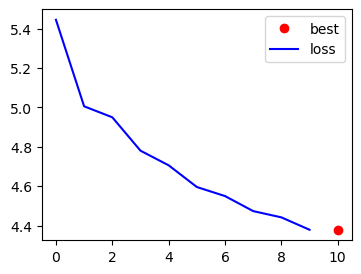

Best epoch so far:  10
Time  21.603 sec

Epoch 11 Batch 37 Loss: 4.4266
Epoch 11 Batch 74 Loss: 4.3244
Epoch 11 Batch 111 Loss: 4.2183
Epoch 11 Batch 148 Loss: 4.2605
Epoch 11 Batch 185 Loss: 4.5011
Epoch 11 Batch 222 Loss: 4.2472

*** Epoch 11 Loss 4.3542 ***

####################
Greedy| Q: Hello   A: i am not 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am going 
Beam  5 |  How are you ?  A: no 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: what 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: yes 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: what 
####################
checkpoint saved!
Best epoch so far:  11
Time  20.491 sec

Epoch 12 Batch 37 Loss: 4.3681
Epoch 12 Batch 74 Loss: 4.2646
Epoch 12 Batch 111 Loss: 4.2541
Epoch 12 Batch 148 Loss: 4.3116
Epoch 12 Batch 185 Loss: 4.2628
Epoch 12 Batch 222 Loss: 4.3868

*** Epoc

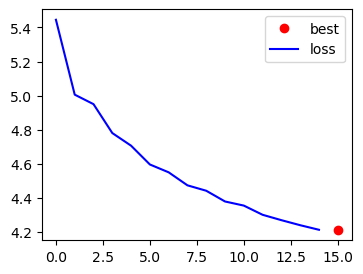

Best epoch so far:  15
Time  21.157 sec

Epoch 16 Batch 37 Loss: 4.2629
Epoch 16 Batch 74 Loss: 4.1706
Epoch 16 Batch 111 Loss: 4.1538
Epoch 16 Batch 148 Loss: 4.1500
Epoch 16 Batch 185 Loss: 4.1051
Epoch 16 Batch 222 Loss: 4.2594

*** Epoch 16 Loss 4.1914 ***

####################
Greedy| Q: Hello   A: i do not know 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: yes 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: i i 
%
Greedy| Q: What is your favorite restaurant ?  A: i am sorry 
Beam  5 |  What is your favorite restaurant ?  A: that 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: i you 
####################
checkpoint saved!
Best epoch so far:  16
Time  21.348 sec

Epoch 17 Batch 37 Loss: 4.2983
Epoch 17 Batch 74 Loss: 4.1426
Epoch 17 Batch 111 Loss: 4.0974
Epoch 17 Batch 148 Loss: 4.1127
Epoch 17 Batch 185 Loss: 4.3334
Epoch 17 Batch 222 Loss: 4.1324

*

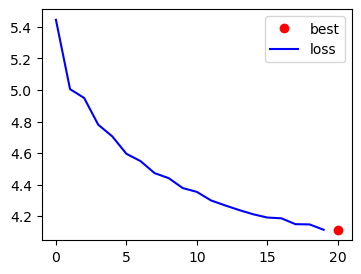

Best epoch so far:  20
Time  20.152 sec

Epoch 21 Batch 37 Loss: 4.1936
Epoch 21 Batch 74 Loss: 4.0169
Epoch 21 Batch 111 Loss: 4.0562
Epoch 21 Batch 148 Loss: 4.0921
Epoch 21 Batch 185 Loss: 4.2232
Epoch 21 Batch 222 Loss: 4.1331

*** Epoch 21 Loss 4.1136 ***

####################
Greedy| Q: Hello   A: i am not 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am sorry 
Beam  5 |  How are you ?  A: it 
%
Greedy| Q: What are you doing ?  A: i am sorry 
Beam  5 |  What are you doing ?  A: yes 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: it 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: that 
####################
checkpoint saved!
Best epoch so far:  21
Time  20.115 sec

Epoch 22 Batch 37 Loss: 4.1590
Epoch 22 Batch 74 Loss: 4.0438
Epoch 22 Batch 111 Loss: 4.0373
Epoch 22 Batch 148 Loss: 4.0037
Epoch 22 Batch 185 Loss: 3.9576
Epoch 22 Batch 222 Loss: 4.1002

*** Epoc

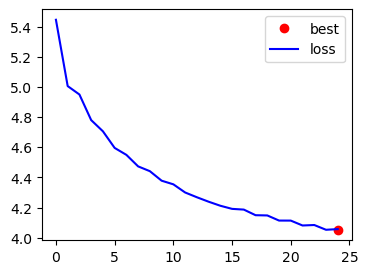

Best epoch so far:  24
Time  20.632 sec

Epoch 26 Batch 37 Loss: 4.1124
Epoch 26 Batch 74 Loss: 3.9973
Epoch 26 Batch 111 Loss: 3.9740
Epoch 26 Batch 148 Loss: 3.9894
Epoch 26 Batch 185 Loss: 3.9316
Epoch 26 Batch 222 Loss: 4.0395

*** Epoch 26 Loss 4.0275 ***

####################
Greedy| Q: Hello   A: i am not 
Beam  5 |  Hello   A: no 
%
Greedy| Q: How are you ?  A: i do not know 
Beam  5 |  How are you ?  A: that 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: it 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: that 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: i you 
####################
checkpoint saved!
Best epoch so far:  26
Time  20.757 sec

Epoch 27 Batch 37 Loss: 4.1640
Epoch 27 Batch 74 Loss: 3.9390
Epoch 27 Batch 111 Loss: 3.9659
Epoch 27 Batch 148 Loss: 4.0119
Epoch 27 Batch 185 Loss: 4.1477
Epoch 27 Batch 222 Loss: 4.0712

*** 

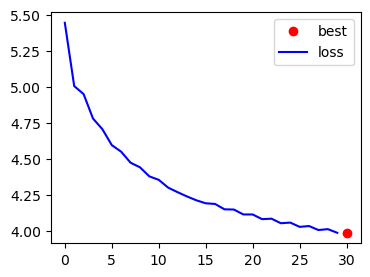

Best epoch so far:  30
Time  21.390 sec

Epoch 31 Batch 37 Loss: 4.1123
Epoch 31 Batch 74 Loss: 3.9143
Epoch 31 Batch 111 Loss: 3.9056
Epoch 31 Batch 148 Loss: 3.9313
Epoch 31 Batch 185 Loss: 4.0752
Epoch 31 Batch 222 Loss: 4.0476

*** Epoch 31 Loss 3.9926 ***

####################
Greedy| Q: Hello   A: i do not know 
Beam  5 |  Hello   A: no 
%
Greedy| Q: How are you ?  A: i am sorry 
Beam  5 |  How are you ?  A: it 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: that 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: i you 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: it 
####################
Best epoch so far:  30
Time  19.715 sec

Epoch 32 Batch 37 Loss: 4.0742
Epoch 32 Batch 74 Loss: 4.0494
Epoch 32 Batch 111 Loss: 3.8832
Epoch 32 Batch 148 Loss: 3.8119
Epoch 32 Batch 185 Loss: 3.9152
Epoch 32 Batch 222 Loss: 3.9740

*** Epoch 32 Loss 3.96

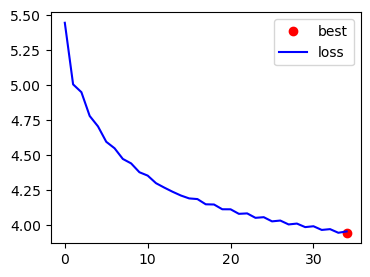

Best epoch so far:  34
Time  19.044 sec

Epoch 36 Batch 37 Loss: 4.0487
Epoch 36 Batch 74 Loss: 4.0326
Epoch 36 Batch 111 Loss: 3.8746
Epoch 36 Batch 148 Loss: 3.7165
Epoch 36 Batch 185 Loss: 3.8606
Epoch 36 Batch 222 Loss: 3.9161

*** Epoch 36 Loss 3.9311 ***

####################
Greedy| Q: Hello   A: i am not 
Beam  5 |  Hello   A: that 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: it 
%
Greedy| Q: What are you doing ?  A: i am 
Beam  5 |  What are you doing ?  A: what 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: it 
%
Greedy| Q: Do you want to go out ?  A: i am sorry 
Beam  5 |  Do you want to go out ?  A: it 
####################
checkpoint saved!
Best epoch so far:  36
Time  19.343 sec

Epoch 37 Batch 37 Loss: 4.0637
Epoch 37 Batch 74 Loss: 3.8476
Epoch 37 Batch 111 Loss: 3.8375
Epoch 37 Batch 148 Loss: 3.8153
Epoch 37 Batch 185 Loss: 3.9475
Epoch 37 Batch 222 Loss: 4.0441

*** Epoch 37 L

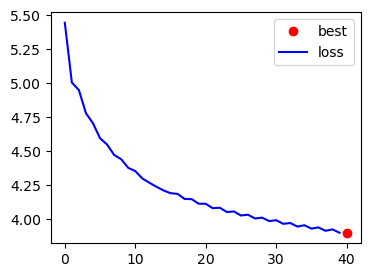

Best epoch so far:  40
Time  19.182 sec

Epoch 41 Batch 37 Loss: 4.0355
Epoch 41 Batch 74 Loss: 3.8112
Epoch 41 Batch 111 Loss: 3.7888
Epoch 41 Batch 148 Loss: 3.7815
Epoch 41 Batch 185 Loss: 3.9062
Epoch 41 Batch 222 Loss: 4.0119

*** Epoch 41 Loss 3.9101 ***

####################
Greedy| Q: Hello   A: hi 
Beam  5 |  Hello   A: hello 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: it 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: it 
%
Greedy| Q: What is your favorite restaurant ?  A: i am 
Beam  5 |  What is your favorite restaurant ?  A: the 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: i i 
####################
Best epoch so far:  40
Time  18.522 sec

Epoch 42 Batch 37 Loss: 4.0396
Epoch 42 Batch 74 Loss: 4.0491
Epoch 42 Batch 111 Loss: 3.8627
Epoch 42 Batch 148 Loss: 3.6798
Epoch 42 Batch 185 Loss: 3.8454
Epoch 42 Batch 222 Loss: 3.8702

*** Epoch 42 Loss 3.8874 ***

#########

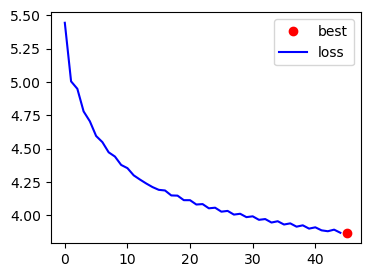

Best epoch so far:  45
Time  20.506 sec

Epoch 46 Batch 37 Loss: 4.0018
Epoch 46 Batch 74 Loss: 3.8629
Epoch 46 Batch 111 Loss: 3.7711
Epoch 46 Batch 148 Loss: 3.7810
Epoch 46 Batch 185 Loss: 4.0764
Epoch 46 Batch 222 Loss: 3.8147

*** Epoch 46 Loss 3.8805 ***

####################
Greedy| Q: Hello   A: i am not 
Beam  5 |  Hello   A: hi 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: i you 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: i you 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: it 
%
Greedy| Q: Do you want to go out ?  A: i am not going to be a good 
Beam  5 |  Do you want to go out ?  A: i i 
####################
Best epoch so far:  45
Time  19.621 sec

Epoch 47 Batch 37 Loss: 4.0083
Epoch 47 Batch 74 Loss: 3.8129
Epoch 47 Batch 111 Loss: 3.7867
Epoch 47 Batch 148 Loss: 3.6951
Epoch 47 Batch 185 Loss: 3.8558
Epoch 47 Batch 222 Loss: 3.9956

*** Epoc

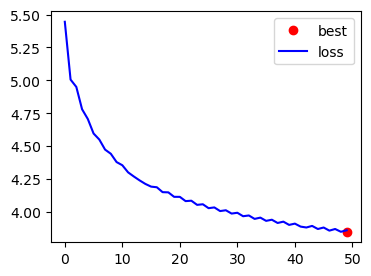

Best epoch so far:  49
Time  18.640 sec

Epoch 51 Batch 37 Loss: 3.9595
Epoch 51 Batch 74 Loss: 3.7813
Epoch 51 Batch 111 Loss: 3.7713
Epoch 51 Batch 148 Loss: 3.7536
Epoch 51 Batch 185 Loss: 3.8122
Epoch 51 Batch 222 Loss: 3.9672

*** Epoch 51 Loss 3.8369 ***

####################
Greedy| Q: Hello   A: hi 
Beam  5 |  Hello   A: hello 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: what 
%
Greedy| Q: What are you doing ?  A: i am not it 
Beam  5 |  What are you doing ?  A: the 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not it 
Beam  5 |  What is your favorite restaurant ?  A: what 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: what 
####################
checkpoint saved!
Best epoch so far:  51
Time  18.939 sec

Epoch 52 Batch 37 Loss: 3.9529
Epoch 52 Batch 74 Loss: 3.7923
Epoch 52 Batch 111 Loss: 3.7429
Epoch 52 Batch 148 Loss: 3.7827
Epoch 52 Batch 185 Loss: 4.0303
Epoch 52 Batch 222 Loss: 3.8116

*** Ep

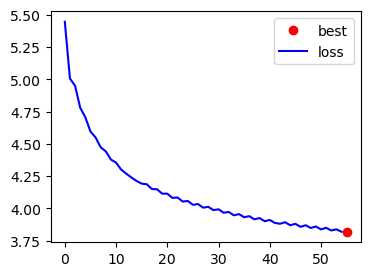

Best epoch so far:  55
Time  19.663 sec

Epoch 56 Batch 37 Loss: 3.9333
Epoch 56 Batch 74 Loss: 4.0923
Epoch 56 Batch 111 Loss: 3.8245
Epoch 56 Batch 148 Loss: 3.6510
Epoch 56 Batch 185 Loss: 3.8055
Epoch 56 Batch 222 Loss: 3.8315

*** Epoch 56 Loss 3.8156 ***

####################
Greedy| Q: Hello   A: what 
Beam  5 |  Hello   A: you 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: the 
%
Greedy| Q: What are you doing ?  A: i am a little bit 
Beam  5 |  What are you doing ?  A: that 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: that 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: it 
####################
checkpoint saved!
Best epoch so far:  56
Time  18.836 sec

Epoch 57 Batch 37 Loss: 3.9175
Epoch 57 Batch 74 Loss: 3.7994
Epoch 57 Batch 111 Loss: 3.7675
Epoch 57 Batch 148 Loss: 3.7511
Epoch 57 Batch 185 Loss: 3.7673
Epoch 57 Batch 222 Loss: 3.9197

*** E

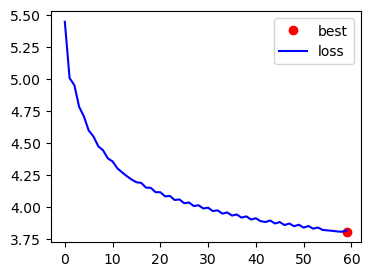

Best epoch so far:  59
Time  18.661 sec

Epoch 61 Batch 37 Loss: 3.8897
Epoch 61 Batch 74 Loss: 3.7694
Epoch 61 Batch 111 Loss: 3.7604
Epoch 61 Batch 148 Loss: 3.6978
Epoch 61 Batch 185 Loss: 3.6807
Epoch 61 Batch 222 Loss: 3.8865

*** Epoch 61 Loss 3.7945 ***

####################
Greedy| Q: Hello   A: hi 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: that 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: it 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not you 
Beam  5 |  What is your favorite restaurant ?  A: that 
%
Greedy| Q: Do you want to go out ?  A: i am sorry 
Beam  5 |  Do you want to go out ?  A: yes 
####################
checkpoint saved!
Best epoch so far:  61
Time  19.211 sec

Epoch 62 Batch 37 Loss: 3.9088
Epoch 62 Batch 74 Loss: 3.7033
Epoch 62 Batch 111 Loss: 3.7206
Epoch 62 Batch 148 Loss: 3.7445
Epoch 62 Batch 185 Loss: 3.9546
Epoch 62 Batch 222 Loss: 3.8253

*** Epoch 

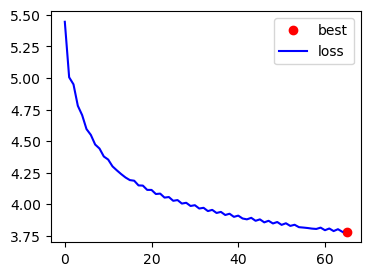

Best epoch so far:  65
Time  20.952 sec

Epoch 66 Batch 37 Loss: 3.9332
Epoch 66 Batch 74 Loss: 3.7308
Epoch 66 Batch 111 Loss: 3.7339
Epoch 66 Batch 148 Loss: 3.7717
Epoch 66 Batch 185 Loss: 3.9185
Epoch 66 Batch 222 Loss: 3.8558

*** Epoch 66 Loss 3.7930 ***

####################
Greedy| Q: Hello   A: hi 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am 
Beam  5 |  How are you ?  A: what 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: that 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: it 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: i i 
####################
Best epoch so far:  65
Time  20.447 sec

Epoch 67 Batch 37 Loss: 3.8799
Epoch 67 Batch 74 Loss: 3.7845
Epoch 67 Batch 111 Loss: 3.7493
Epoch 67 Batch 148 Loss: 3.6702
Epoch 67 Batch 185 Loss: 3.6781
Epoch 67 Batch 222 Loss: 3.8078

*** Epoch 67 Loss 3.7742 ***

########

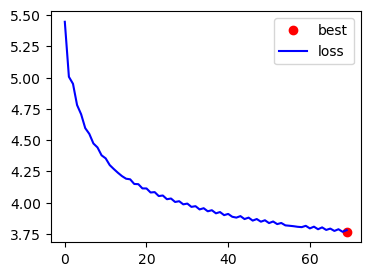

Best epoch so far:  69
Time  19.273 sec

Epoch 71 Batch 37 Loss: 3.8890
Epoch 71 Batch 74 Loss: 3.7709
Epoch 71 Batch 111 Loss: 3.7053
Epoch 71 Batch 148 Loss: 3.6561
Epoch 71 Batch 185 Loss: 3.6588
Epoch 71 Batch 222 Loss: 3.7835

*** Epoch 71 Loss 3.7619 ***

####################
Greedy| Q: Hello   A: i do not know 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am not you 
Beam  5 |  How are you ?  A: what 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: i i 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: the 
%
Greedy| Q: Do you want to go out ?  A: i am not you 
Beam  5 |  Do you want to go out ?  A: i i 
####################
checkpoint saved!
Best epoch so far:  71
Time  18.928 sec

Epoch 72 Batch 37 Loss: 3.9173
Epoch 72 Batch 74 Loss: 3.6551
Epoch 72 Batch 111 Loss: 3.7124
Epoch 72 Batch 148 Loss: 3.7326
Epoch 72 Batch 185 Loss: 3.8424
Epoch 72 Batch 222 Loss: 3.845

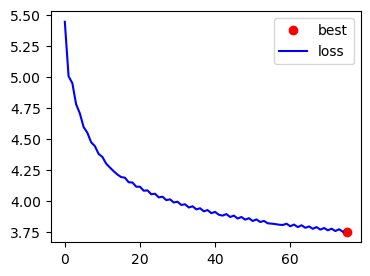

Best epoch so far:  75
Time  17.952 sec

Epoch 76 Batch 37 Loss: 3.9097
Epoch 76 Batch 74 Loss: 3.6748
Epoch 76 Batch 111 Loss: 3.6670
Epoch 76 Batch 148 Loss: 3.6796
Epoch 76 Batch 185 Loss: 3.8400
Epoch 76 Batch 222 Loss: 3.8545

*** Epoch 76 Loss 3.7645 ***

####################
Greedy| Q: Hello   A: what 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am sorry 
Beam  5 |  How are you ?  A: that 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: the 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: no 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: i 
####################
Best epoch so far:  75
Time  19.149 sec

Epoch 77 Batch 37 Loss: 3.8572
Epoch 77 Batch 74 Loss: 3.8070
Epoch 77 Batch 111 Loss: 3.6804
Epoch 77 Batch 148 Loss: 3.5523
Epoch 77 Batch 185 Loss: 3.6835
Epoch 77 Batch 222 Loss: 3.7581

*** Epoch 77 Loss 3.7442 ***

###

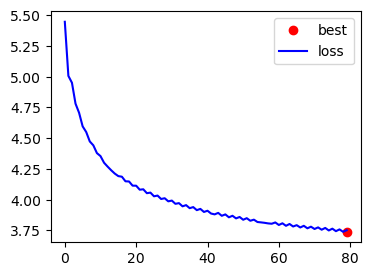

Best epoch so far:  79
Time  19.170 sec

Epoch 81 Batch 37 Loss: 3.8703
Epoch 81 Batch 74 Loss: 3.8437
Epoch 81 Batch 111 Loss: 3.6909
Epoch 81 Batch 148 Loss: 3.5396
Epoch 81 Batch 185 Loss: 3.6621
Epoch 81 Batch 222 Loss: 3.7028

*** Epoch 81 Loss 3.7326 ***

####################
Greedy| Q: Hello   A: hi 
Beam  5 |  Hello   A: you 
%
Greedy| Q: How are you ?  A: i am 
Beam  5 |  How are you ?  A: i i 
%
Greedy| Q: What are you doing ?  A: i am going to do 
Beam  5 |  What are you doing ?  A: what 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not you 
Beam  5 |  What is your favorite restaurant ?  A: i i 
%
Greedy| Q: Do you want to go out ?  A: i am not a good 
Beam  5 |  Do you want to go out ?  A: what 
####################
checkpoint saved!
Best epoch so far:  81
Time  20.137 sec

Epoch 82 Batch 37 Loss: 3.8970
Epoch 82 Batch 74 Loss: 3.6390
Epoch 82 Batch 111 Loss: 3.6356
Epoch 82 Batch 148 Loss: 3.6458
Epoch 82 Batch 185 Loss: 3.7895
Epoch 82 Batch 222 Loss: 3.8589



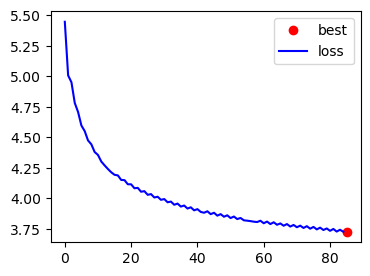

Best epoch so far:  85
Time  19.386 sec

Epoch 86 Batch 37 Loss: 3.8755
Epoch 86 Batch 74 Loss: 3.6468
Epoch 86 Batch 111 Loss: 3.6607
Epoch 86 Batch 148 Loss: 3.5450
Epoch 86 Batch 185 Loss: 3.7488
Epoch 86 Batch 222 Loss: 3.8671

*** Epoch 86 Loss 3.7218 ***

####################
Greedy| Q: Hello   A: what 
Beam  5 |  Hello   A: hi i 
%
Greedy| Q: How are you ?  A: i am not going to 
Beam  5 |  How are you ?  A: that 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: i i 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not going to do 
Beam  5 |  What is your favorite restaurant ?  A: i you 
%
Greedy| Q: Do you want to go out ?  A: i am not 
Beam  5 |  Do you want to go out ?  A: i i 
####################
checkpoint saved!
Best epoch so far:  86
Time  20.421 sec

Epoch 87 Batch 37 Loss: 3.8675
Epoch 87 Batch 74 Loss: 3.7210
Epoch 87 Batch 111 Loss: 3.6264
Epoch 87 Batch 148 Loss: 3.6406
Epoch 87 Batch 185 Loss: 3.9924
Epoch 87 Batch 222 Loss

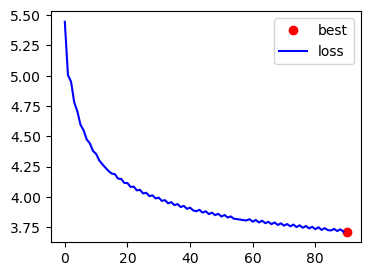

Best epoch so far:  90
Time  18.458 sec

Epoch 91 Batch 37 Loss: 3.8396
Epoch 91 Batch 74 Loss: 3.6563
Epoch 91 Batch 111 Loss: 3.6336
Epoch 91 Batch 148 Loss: 3.6549
Epoch 91 Batch 185 Loss: 3.9166
Epoch 91 Batch 222 Loss: 3.7049

*** Epoch 91 Loss 3.7252 ***

####################
Greedy| Q: Hello   A: hi 
Beam  5 |  Hello   A: yes 
%
Greedy| Q: How are you ?  A: i am not going to be 
Beam  5 |  How are you ?  A: it 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: i i 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: it 
%
Greedy| Q: Do you want to go out ?  A: i am not going to do 
Beam  5 |  Do you want to go out ?  A: that 
####################
Best epoch so far:  90
Time  19.236 sec

Epoch 92 Batch 37 Loss: 3.8329
Epoch 92 Batch 74 Loss: 3.6653
Epoch 92 Batch 111 Loss: 3.6460
Epoch 92 Batch 148 Loss: 3.5328
Epoch 92 Batch 185 Loss: 3.6996
Epoch 92 Batch 222 Loss: 3.8429

*** Epoch 92

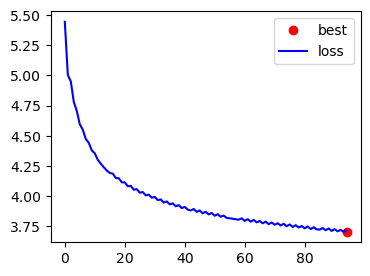

Best epoch so far:  94
Time  20.194 sec

Epoch 96 Batch 37 Loss: 3.7905
Epoch 96 Batch 74 Loss: 3.6927
Epoch 96 Batch 111 Loss: 3.6504
Epoch 96 Batch 148 Loss: 3.6193
Epoch 96 Batch 185 Loss: 3.6742
Epoch 96 Batch 222 Loss: 3.8589

*** Epoch 96 Loss 3.7015 ***

####################
Greedy| Q: Hello   A: what do you mean 
Beam  5 |  Hello   A: hi i 
%
Greedy| Q: How are you ?  A: i am not it 
Beam  5 |  How are you ?  A: nothing 
%
Greedy| Q: What are you doing ?  A: i am not 
Beam  5 |  What are you doing ?  A: what 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: the 
%
Greedy| Q: Do you want to go out ?  A: i am not you 
Beam  5 |  Do you want to go out ?  A: i i 
####################
checkpoint saved!
Best epoch so far:  96
Time  18.420 sec

Epoch 97 Batch 37 Loss: 3.8177
Epoch 97 Batch 74 Loss: 3.6055
Epoch 97 Batch 111 Loss: 3.6514
Epoch 97 Batch 148 Loss: 3.6303
Epoch 97 Batch 185 Loss: 3.9083
Epoch 97 Batch 222 Loss

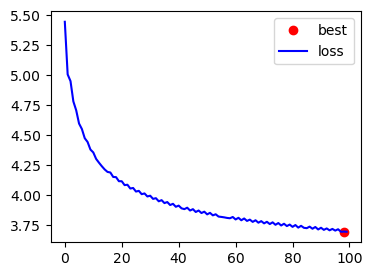

Best epoch so far:  98
Time  19.678 sec



In [28]:
import math
X, y = [], []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def plot_history():
    plt.figure(figsize=(4,3))
    plt.plot(best_ep,smallest_loss,'ro')
    plt.plot(history['loss'],'b-')
    plt.legend(['best','loss'])
    plt.show()

for ep in range(current_ep,EPOCHS+1):
    current_ep = ep
    start = time.time()
    total_loss = 0
    btch = 1

    for p in pairs_final_train:

        question = p[0]
        label = p[1]
        # find the index of each word of the caption in vocabulary
        question_seq = [wordtoix[word] for word in question.split(' ') if word in wordtoix]
        label_seq = [wordtoix[word] for word in label.split(' ') if word in wordtoix]
        # encoder input and decoder input and label
        enc_in_seq = pad_sequences([question_seq], maxlen=max_len_q)[0]
        dec_out_seq = pad_sequences([label_seq], maxlen=max_len_a)[0]

        X.append(enc_in_seq)
        y.append(dec_out_seq)

        if len(X) == batch_size :

            batch_loss = train_step(
                torch.Tensor(X).to(torch.int32),
                torch.Tensor(y).to(torch.long),
                enc_hidden,
                device
                )
            if not math.isnan(batch_loss):
              total_loss += batch_loss
              btch += 1
            X , y = [], []
            if btch % (steps_per_epoch//6) == 0:
                print('Epoch {} Batch {} Loss: {:.4f}'.format(ep , btch, batch_loss))
    epoch_loss =  total_loss / steps_per_epoch
    print('\n*** Epoch {} Loss {:.4f} ***\n'.format(ep ,epoch_loss))
    history['loss'].append(epoch_loss)


    test_bot(beam=True)

    if epoch_loss < smallest_loss:
        smallest_loss = epoch_loss
        best_ep = ep

        torch.save(encoder, f'encoder_{ep}.pth')
        torch.save(decoder, f'decoder_{ep}.pth')

        print('checkpoint saved!')

    if ep % 5 == 0:
        plot_history()

    print('Best epoch so far: ',best_ep)
    print('Time  {:.3f} sec\n'.format(time.time() - start))

    print('=' * 40)

Now we can load our best model and chat with our system. We also plot the attention weights.

In [78]:
#best_ep = 98 # set best_ep value found
encoder = torch.load(f'encoder_{best_ep}.pth', weights_only=False)
decoder = torch.load(f'decoder_{best_ep}.pth', weights_only=False)
print('load best checkpoint from ep:', best_ep)
test_bot(k=5,beam=True)

load best checkpoint from ep: 98
####################
Greedy| Q: Hello   A: i am not going to 
Beam  5 |  Hello   A: you 
%
Greedy| Q: How are you ?  A: i am not 
Beam  5 |  How are you ?  A: i 
%
Greedy| Q: What are you doing ?  A: i am not you 
Beam  5 |  What are you doing ?  A: nothing 
%
Greedy| Q: What is your favorite restaurant ?  A: i am not 
Beam  5 |  What is your favorite restaurant ?  A: i i 
%
Greedy| Q: Do you want to go out ?  A: i am not going to do 
Beam  5 |  Do you want to go out ?  A: i i 
####################


Input: how old are you
Predicted answer: i am sorry 


/tmp/ipykernel_154/4229615246.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_154/4229615246.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


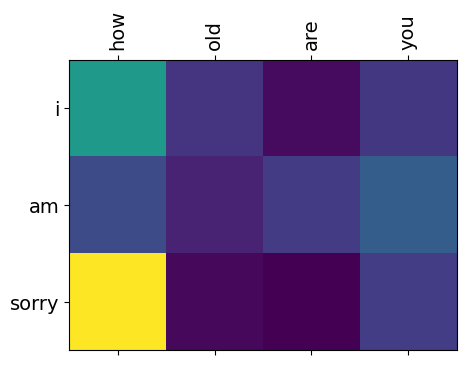

In [76]:
q = "How old are you"
answer(q, training=False)

Input: do you drink
Predicted answer: i am not 


/tmp/ipykernel_154/4229615246.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_154/4229615246.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


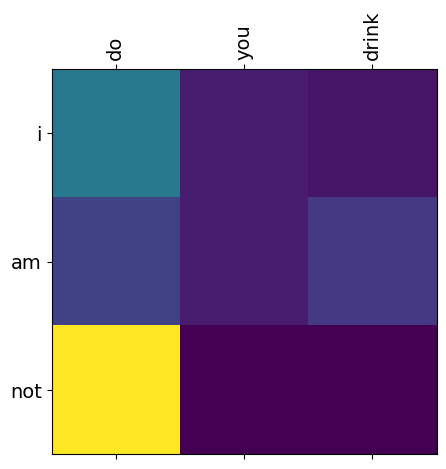

In [77]:
q = "Do you drink"
answer(q, training=False)

**Task 3** Let's look at the attention weights and compare them after 5, 50 and 100 epochs. Instead of evaluating by an automatic evaluation method, you can show us 10 predictions for each model. Answer the following questions based on your predictions, giving examples and/or explaining the evidence for your answers.

**<font color="red">The answer to the questions below are from the anaylsis done on task 3, refer to code segement TASK 3 analysis below. I have also include these with figures in the report for more clarirty and convenience.</font>**


1. **Did the models learn to track local relations between words?** 

>  <font color="skyBlue"> 
>  Yes, the models learned to track local word relations, but in different ways across the train epochs. </font>

>  <font color="skyBlue"> 
> For simplicity, let's take a common test query: "Do you like movies" for all of the epochs. In addition, we can refer to the their heatmaps, relevant summaries, and statisitcs. Firstly, from the ANALYSIS OF SYNTACTIC RELATIONS, for epoch 5, we can see that low average difference values for related word pairs approx. 0.0005 for subject-verb and 0.0021 for verb-object. This shows that the model strongly attends to adjacent words togther. As for epoch 51 & 98, while the difference scores increased slightly, they remained low, especially for subject-verb pairs 0.0441 and 0.0328. </font>

>  <font color="skyBlue"> 
> Furthermore, from the heatmap (for epoch 5,test query: "Do you like movies"), we see some consistent attention patterns across the adjacent words. Whereas, in heatmap (for epoch 51 & 98,test query: "Do you like movies"), the model develops more selective attention, but recognizes word relationships. </font>

>  <font color="skyBlue"> 
> Moreover, the extremely low difference scores for syntactic pairs like "time is" 0.0002 and "favorite restaurant" 0.0001 show strong tracking of local word dependencies. </font>


> <font color="skyBlue">
> In Conclusion, Yes, the model does learn stronger local word relations especially vO by the later epochs. As for, earlier epoch 5, it nearly ignores them or lumps everything together. By epoch 98, it shows more "awareness" of local syntactic connections. </font>


2. **Did the models attend to the least frequent tokens in an utterance? Can you see signs of overfitting in models that hang on to the least frequent words?**

> <font color="skyBlue">
> No, the models consistently favors common tokens over rarer ones.</font>

> <font color="skyBlue">
> Moreover, common words received more attention than medium-frequency words across all the epochs. As the attention gap widens with training 0.0784 vs 0.0775 in Epoch 5 and 0.1335 vs 0.1062 in Epoch 98, Question words "what, where" and functional verbs "tell, do" receive the highest attention in later epochs. </font>

> <font color="skyBlue">
> Finally, there are no signs of overfitting to rare words. It is actually the  opposite, which occurs. For instance, the model focuses on high-frequency functional words that drive query intent. This suggests that it is learning general patterns rather than overfitting to uncommon tokens. </font>


3. **Did the models learn to track some major syntactic relations in the utterances (e.g. subject-verb, verb-object)?**

> <font color="skyBlue">
> Yes, the models track syntactic relations effectively. For example, the Subject-verb (SV) pairs, consistently tracked "you want", "time is" with very low difference scores. Whereas, the VO pairs had more selective attention in later epochs. Also, adjective-noun pairs, consistently recognized "favorite restaurant" across all epochs.</font>

> <font color="skyBlue">
> For later epochs, the increase in difference values suggests that the model becomes more selective about which syntactic relationships to emphasize, rather than uniformly attending to all related pairs.</font>


4. **Do they learn to encode some other linguistic features? Do they capture part-of-speech tags (POS tags)?**

> <font color="skyBlue">
> Yes, the models do develop sensitivity to part-of-speech categories. In epoch 5, we can see relatively uniform attention across POS tags approx. 0.0760-0.0804. Then, around epoch 51, it begins differentiating with apprix. 0.0561-0.1439, with higher attention to question words. Finally, around epoch 98, we can see dramatic specialization approx. 0.0570-0.3112. Here, we can see the highest attention for WP (wh-pronouns, approx. 0.3112), MD (modals, approx. 0.3094), WRB (wh-adverbs, approx. 0.3086). In addition, we also see lowest attention for PRP$ (possessive pronouns, approx. 0.0570), VBZ (3rd person verbs, approx. 0.0612) </font>

> <font color="skyBlue">
> Hence, we can see that the model learns to prioritize words that define query intent "what, where, can", while de-emphasizing more predictable elements.</font>


5. **What is the effect of more training on the length of responss?**

>  ** Refer to Effect of "Training on response length" figure below.**


> <font color="skyBlue">
> Training increases response length for greedy decoding but has very minimal impact on beam search. For greedy decoding, in epoch 5, we see fixed 2-token responses e.g. "i am". As for epoch 51, we see an avg of approx. 2.8 tokens e.g. "i am not". Lastly, for epoch 98, we see an avg of approx. 5.5 tokens e.g. "i am not going to do". </font>


> <font color="skyBlue">
> Now, for beam search, we can see that it consistently remains short with approx. 1-1.1 tokens across all epochs. For this, repsonses like "what", "that", "yes" regardless of training can be seen often.</font>

> <font color="skyBlue">
> As shown in the Effect of "Training on response length" figure, we can see that greedy decoding responses lengthen progressively, whereas beam search remains flat. This suggests that the model learns a specific pattern that  works better with greedy search.</font>


6. **In some instances, by the time the decoder has to generate the beginning of a response, it may already forget the most relevant early query tokens. Can you suggest ways to change the training pipeline to make it easier for the model to remember the beginning of the query when it starts to generate the response?**

> <font color="skyBlue">
> For instance we can use something like the coverage Mechanism in attention. This would help us track how many times each encoder token has been "attended" to, so we do not forget or reignore earlier tokens. Another thing we could do is increase the model capacity, a 50 dim GRU is rather small for open domain conversations. Therefore a larger GRU or a transformer with multi-head attention will hold more context.</font>


# Task 3 Code To help answer the above question with clear visuals and information

In [81]:

import nltk
from nltk.tag import pos_tag
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Download NLTK data for POS tagging
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [82]:
# Test queries
test_queries = [
    "Hello",
    "How are you",
    "What are you doing",
    "What is your favorite restaurant",
    "Do you want to go out",
    "Tell me about yourself",
    "Do you like movies",
    "What time is it",
    "Where are you from",
    "Can you help me"
]

In [83]:
# Complete analysis function
def task3_analysis(epochs_to_analyze=[5, 51, 98], device="cpu"):
    """Complete analysis for Task 3"""
    global encoder, decoder  #  modifying the global variables
    
    # Store all results for analysis
    all_results = {epoch: [] for epoch in epochs_to_analyze}
    word_frequencies = calculate_word_frequencies(pairs_final)
    
    for epoch in epochs_to_analyze:
        print(f"\n{'='*40}\nAnalyzing Epoch {epoch} Model\n{'='*40}")
        
        try:
            # Load models into the global variables
            encoder = torch.load(f'encoder_{epoch}.pth', weights_only=False)
            decoder = torch.load(f'decoder_{epoch}.pth', weights_only=False)
            
            # Set to evaluation mode
            encoder.eval()
            decoder.eval()
            
            # Process each query
            for query in test_queries:
                print(f"\nQuery: {query}")
                
                # Get greedy and beam search responses
                greedy_response = answer(query, training=True, device=device)
                beam_response = beam_search(query, k=5, device=device)
                
                print(f"Greedy: {greedy_response}")
                print(f"Beam-5: {beam_response}")
                
                # Get attention patterns and analyze
                result, sentence, attention_plot = evaluate(query, device)
                
                # Process tokens
                input_tokens = sentence.split()
                output_tokens = result.split()
                
                # Trim attention matrix to match tokens
                if len(output_tokens) > 0 and len(input_tokens) > 0:
                    attn = attention_plot[:len(output_tokens), :len(input_tokens)]
                    
                    # Store result
                    result_data = {
                        'query': query,
                        'greedy_response': greedy_response,
                        'beam_response': beam_response,
                        'input_tokens': input_tokens,
                        'output_tokens': output_tokens,
                        'attention': attn,
                        'greedy_length': len(greedy_response.split()),
                        'beam_length': len(beam_response.split())
                    }
                    
                    all_results[epoch].append(result_data)
                    
                    # Create visualization
                    try:
                        visualize_attention(attn, input_tokens, output_tokens, epoch, query)
                    except Exception as e:
                        print(f"Visualization error: {e}")
            
            # Summarize for this epoch
            summarize_epoch_results(all_results[epoch], epoch, word_frequencies)
            
        except FileNotFoundError:
            print(f"Model files for epoch {epoch} not found")
    
    # Generate comparative analyses
    analyze_response_lengths(all_results)
    analyze_word_frequency_attention(all_results, word_frequencies)
    analyze_syntactic_relations(all_results)
    analyze_pos_patterns(all_results)
    
    return all_results

# this Helper function calculates word frequencies from train data
def calculate_word_frequencies(pairs):
    word_count = {}
    for pair in pairs:
        for sentence in pair:
            for word in sentence.split():
                word_count[word] = word_count.get(word, 0) + 1
    return word_count

# attention visualization improvement
def visualize_attention(attention, input_tokens, output_tokens, epoch, query):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1)
    
    # Create heatmap
    im = ax.matshow(attention, cmap='viridis')
    fig.colorbar(im)
    
    # Label axes
    fontdict = {'fontsize': 12}
    ax.set_xticks(range(len(input_tokens)))
    ax.set_yticks(range(len(output_tokens)))
    ax.set_xticklabels(input_tokens, fontdict=fontdict, rotation=45)
    ax.set_yticklabels(output_tokens, fontdict=fontdict)
    
    # add the POS tags
    try:
        pos_tags = [tag for _, tag in pos_tag(input_tokens)]
        for i, tag in enumerate(pos_tags):
            ax.text(i, -0.5, tag, color='blue', fontsize=10, ha='center')
    except Exception as e:
        print(f"POS tagging error: {e}")
    
    # mark maximum attention points
    for i in range(min(len(output_tokens), attention.shape[0])):
        if attention.shape[1] > 0:
            max_idx = attention[i].argmax()
            if max_idx < len(input_tokens):
                ax.text(max_idx, i, 'X', color='red', fontsize=12, ha='center', va='center')
    
    # mark the syntactic patterns
    try:
        pos_tags = [tag for _, tag in pos_tag(input_tokens)]
        for i in range(len(pos_tags)-1):
            if i < len(input_tokens)-1:
                # Subject-verb relation
                if (pos_tags[i].startswith('NN') or pos_tags[i] == 'PRP') and pos_tags[i+1].startswith('VB'):
                    rect = plt.Rectangle((i-0.5, -0.8), 2, 0.2, fill=True, color='green', alpha=0.6)
                    ax.add_patch(rect)
                    ax.text(i+0.5, -1.0, 'SUBJ-VERB', fontsize=8, ha='center')
                
                # Verb-object relation
                if pos_tags[i].startswith('VB') and (pos_tags[i+1].startswith('NN') or pos_tags[i+1] == 'PRP'):
                    rect = plt.Rectangle((i-0.5, -1.2), 2, 0.2, fill=True, color='orange', alpha=0.6)
                    ax.add_patch(rect)
                    ax.text(i+0.5, -1.4, 'VERB-OBJ', fontsize=8, ha='center')
                
                # Adjective-noun relation
                if pos_tags[i].startswith('JJ') and pos_tags[i+1].startswith('NN'):
                    rect = plt.Rectangle((i-0.5, -1.6), 2, 0.2, fill=True, color='purple', alpha=0.6)
                    ax.add_patch(rect)
                    ax.text(i+0.5, -1.8, 'ADJ-NOUN', fontsize=8, ha='center')
    except Exception as e:
        print(f"Error highlighting syntax: {e}")
    
    ax.set_title(f"Epoch {epoch} - Query: {query}")
    plt.tight_layout()
    plt.show()

# Summarize results for a single epoch
def summarize_epoch_results(results, epoch, word_frequencies):
    print(f"\nSummary for Epoch {epoch}:")
    
    # Response stats
    greedy_lengths = [r['greedy_length'] for r in results]
    beam_lengths = [r['beam_length'] for r in results]
    
    print(f"Greedy response lengths: Avg={np.mean(greedy_lengths):.1f}, Min={min(greedy_lengths)}, Max={max(greedy_lengths)}")
    print(f"Beam response lengths: Avg={np.mean(beam_lengths):.1f}, Min={min(beam_lengths)}, Max={max(beam_lengths)}")
    
    # most common responses
    greedy_responses = [r['greedy_response'] for r in results]
    beam_responses = [r['beam_response'] for r in results]
    
    print("\nMost common greedy responses:")
    for resp, count in Counter(greedy_responses).most_common(2):
        print(f"  '{resp}': {count} times")
    
    print("\nMost common beam responses:")
    for resp, count in Counter(beam_responses).most_common(2):
        print(f"  '{resp}': {count} times")

# Analyze response lengths across epochs
def analyze_response_lengths(all_results):
    print("\n" + "="*80)
    print("ANALYSIS OF RESPONSE LENGTHS")
    print("="*80)
    
    # Set up plot
    plt.figure(figsize=(12, 6))
    
    # Plot for each epoch
    markers = ['o', 's', '^', 'd', '*']
    for i, (epoch, results) in enumerate(all_results.items()):
        if not results:
            continue
            
        greedy_lengths = [r['greedy_length'] for r in results]
        beam_lengths = [r['beam_length'] for r in results]
        
        plt.plot(range(len(greedy_lengths)), greedy_lengths, 
                 marker=markers[i % len(markers)], label=f'Epoch {epoch} Greedy')
        plt.plot(range(len(beam_lengths)), beam_lengths, 
                 marker=markers[i % len(markers)], linestyle='--', label=f'Epoch {epoch} Beam')
        
        print(f"Epoch {epoch}:")
        print(f"  Greedy: Avg={np.mean(greedy_lengths):.2f}, Min={min(greedy_lengths)}, Max={max(greedy_lengths)}")
        print(f"  Beam: Avg={np.mean(beam_lengths):.2f}, Min={min(beam_lengths)}, Max={max(beam_lengths)}")
    
    plt.xlabel('Query Index')
    plt.ylabel('Response Length (tokens)')
    plt.title('Effect of Training on Response Length')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [84]:
# Analyze attention to rare vs. common words
def analyze_word_frequency_attention(all_results, word_frequencies):
    print("\n" + "="*80)
    print("ANALYSIS OF ATTENTION TO RARE VS COMMON TOKENS")
    print("="*80)
    
    # frequency categories
    frequency_ranges = {
        'rare': (1, 10),      # 1-10 occurrences
        'medium': (11, 100),  # 11-100 occurrences
        'common': (101, float('inf'))  # >100 occurrences
    }
    
    for epoch, results in all_results.items():
        print(f"\nEpoch {epoch}:")
        
        frequency_attention = {cat: [] for cat in frequency_ranges}
        
        for result in results:
            attn = result['attention']
            input_tokens = result['input_tokens']
            
            if attn.size == 0:
                continue
                
            # Calculate average attention by word frequency
            for i, token in enumerate(input_tokens):
                if i < attn.shape[1]:
                    freq = word_frequencies.get(token, 0)
                    avg_attn = attn[:, i].mean()
                    
                    # Categorize by frequency
                    for cat, (min_f, max_f) in frequency_ranges.items():
                        if min_f <= freq <= max_f:
                            frequency_attention[cat].append((token, freq, avg_attn))
        
        # Print results by category
        for cat, examples in frequency_attention.items():
            if examples:
                avg_attn = sum(a for _, _, a in examples) / len(examples)
                print(f"{cat.capitalize()} words ({len(examples)} tokens): Avg attention = {avg_attn:.4f}")
                
                # Show examples of highest attention words in this category
                print("  Highest attention examples:")
                for token, freq, attn in sorted(examples, key=lambda x: x[2], reverse=True)[:3]:
                    print(f"    '{token}' (freq={freq}): {attn:.4f}")

# Analyze syntactic relations
def analyze_syntactic_relations(all_results):
    print("\n" + "="*80)
    print("ANALYSIS OF SYNTACTIC RELATIONS")
    print("="*80)
    
    relation_types = {
        'subject_verb': {},  # epoch -> list of (word1, word2, attention_diff)
        'verb_object': {},
        'adj_noun': {}
    }
    
    for epoch, results in all_results.items():
        for rel_type in relation_types:
            relation_types[rel_type][epoch] = []
            
        for result in results:
            attn = result['attention']
            input_tokens = result['input_tokens']
            
            if attn.size == 0 or len(input_tokens) < 2:
                continue
                
            try:
                pos_tags = [tag for _, tag in pos_tag(input_tokens)]
                
                # Find syntactic relations
                for i in range(len(input_tokens)-1):
                    if i >= attn.shape[1]-1:
                        continue
                        
                    # For each output token, check attention similarity
                    for t in range(min(attn.shape[0], len(result['output_tokens']))):
                        diff = abs(attn[t, i] - attn[t, i+1])
                        
                        # Subject-verb
                        if (pos_tags[i].startswith('NN') or pos_tags[i] == 'PRP') and pos_tags[i+1].startswith('VB'):
                            relation_types['subject_verb'][epoch].append((input_tokens[i], input_tokens[i+1], diff))
                        
                        # Verb-object
                        if pos_tags[i].startswith('VB') and (pos_tags[i+1].startswith('NN') or pos_tags[i+1] == 'PRP'):
                            relation_types['verb_object'][epoch].append((input_tokens[i], input_tokens[i+1], diff))
                        
                        # Adjective-noun
                        if pos_tags[i].startswith('JJ') and pos_tags[i+1].startswith('NN'):
                            relation_types['adj_noun'][epoch].append((input_tokens[i], input_tokens[i+1], diff))
            except Exception as e:
                print(f"Error analyzing syntax: {e}")
    
    # Print results for each relation type across epochs
    for rel_type, epoch_data in relation_types.items():
        print(f"\n{rel_type.replace('_', '-')} relation analysis:")
        
        for epoch, examples in sorted(epoch_data.items()):
            if examples:
                avg_diff = sum(diff for _, _, diff in examples) / len(examples)
                print(f"  Epoch {epoch}: {len(examples)} instances, avg diff={avg_diff:.4f}")
                
                # Lower diff means more similar attention (better tracking)
                print("  Examples:")
                for w1, w2, diff in sorted(examples, key=lambda x: x[2])[:2]:
                    print(f"    '{w1} {w2}' (diff={diff:.4f})")

# analyze POS tag patterns
def analyze_pos_patterns(all_results):
    print("\n" + "="*80)
    print("ANALYSIS OF PART-OF-SPEECH PATTERNS")
    print("="*80)
    
    pos_attention = {}  # epoch -> pos -> list of attention values
    
    for epoch, results in all_results.items():
        pos_attention[epoch] = {}
        
        for result in results:
            attn = result['attention']
            input_tokens = result['input_tokens']
            
            if attn.size == 0:
                continue
                
            try:
                pos_tags = [tag for _, tag in pos_tag(input_tokens)]
                
                # Collect attention by POS tag
                for i, tag in enumerate(pos_tags):
                    if i < attn.shape[1]:
                        avg_attn = attn[:, i].mean()
                        
                        if tag not in pos_attention[epoch]:
                            pos_attention[epoch][tag] = []
                            
                        pos_attention[epoch][tag].append(avg_attn)
            except Exception as e:
                print(f"POS analysis error: {e}")
    
    # Analyze POS tags for each epoch
    for epoch, pos_data in sorted(pos_attention.items()):
        print(f"\nEpoch {epoch} - Average attention by POS tag:")
        
        # Calculate average attention per tag
        avg_by_pos = {}
        for tag, values in pos_data.items():
            if values:
                avg = sum(values) / len(values)
                count = len(values)
                avg_by_pos[tag] = (avg, count)
        
        # Print sorted by attention value
        for tag, (avg, count) in sorted(avg_by_pos.items(), key=lambda x: x[1][0], reverse=True):
            print(f"  {tag}: {avg:.4f} ({count} occurrences)")


Analyzing Epoch 5 Model

Query: Hello


/tmp/ipykernel_154/642584176.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder = torch.load(f'encoder_{epoch}.pth')
/tmp/ipykernel_154/642584176.py:16: FutureWarn

Greedy: i am 
Beam-5: what 


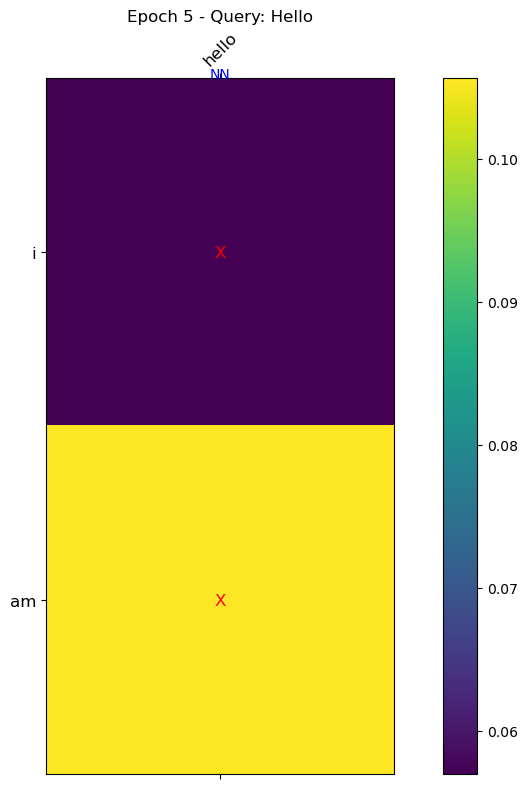


Query: How are you
Greedy: i am 
Beam-5: what 


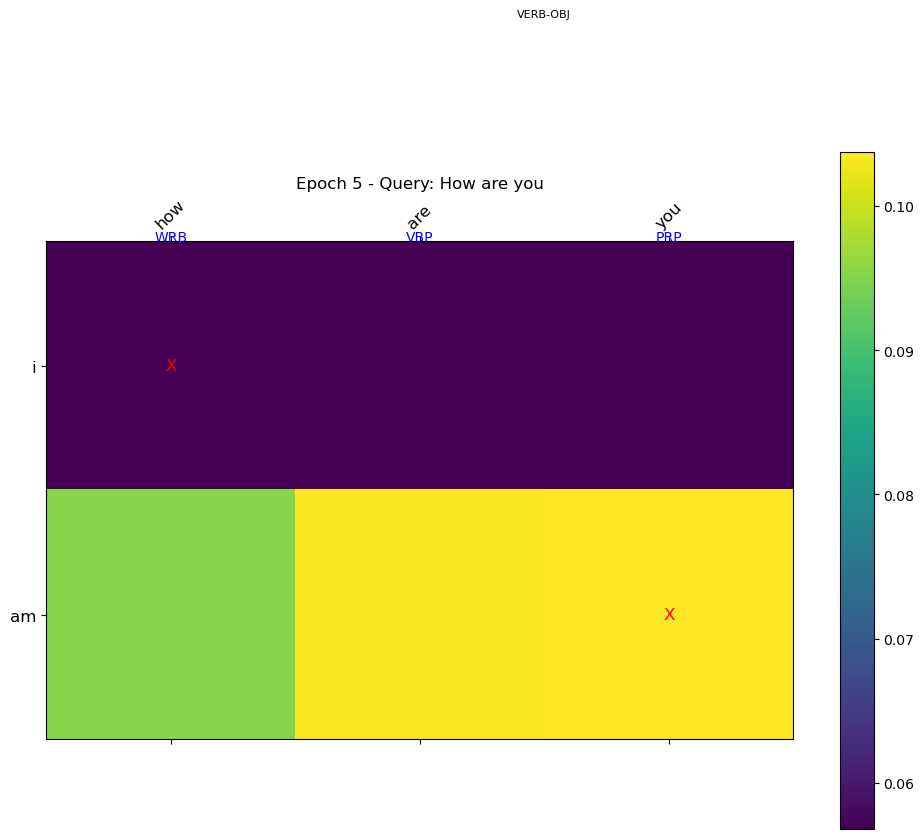


Query: What are you doing
Greedy: i am 
Beam-5: what 


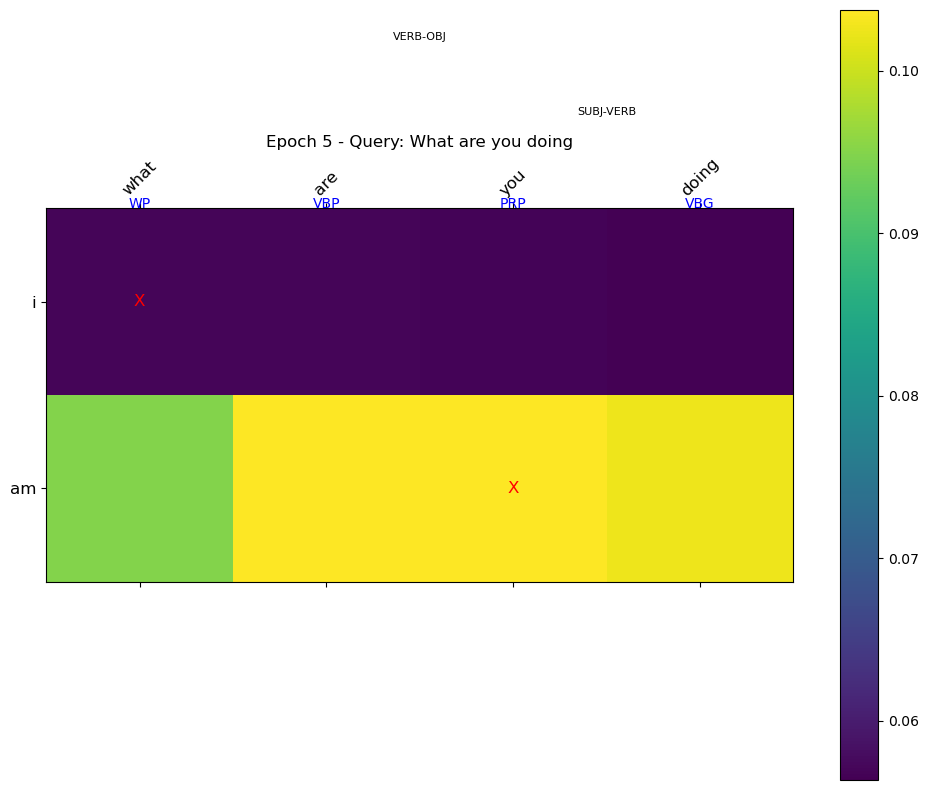


Query: What is your favorite restaurant
Greedy: i am 
Beam-5: what 


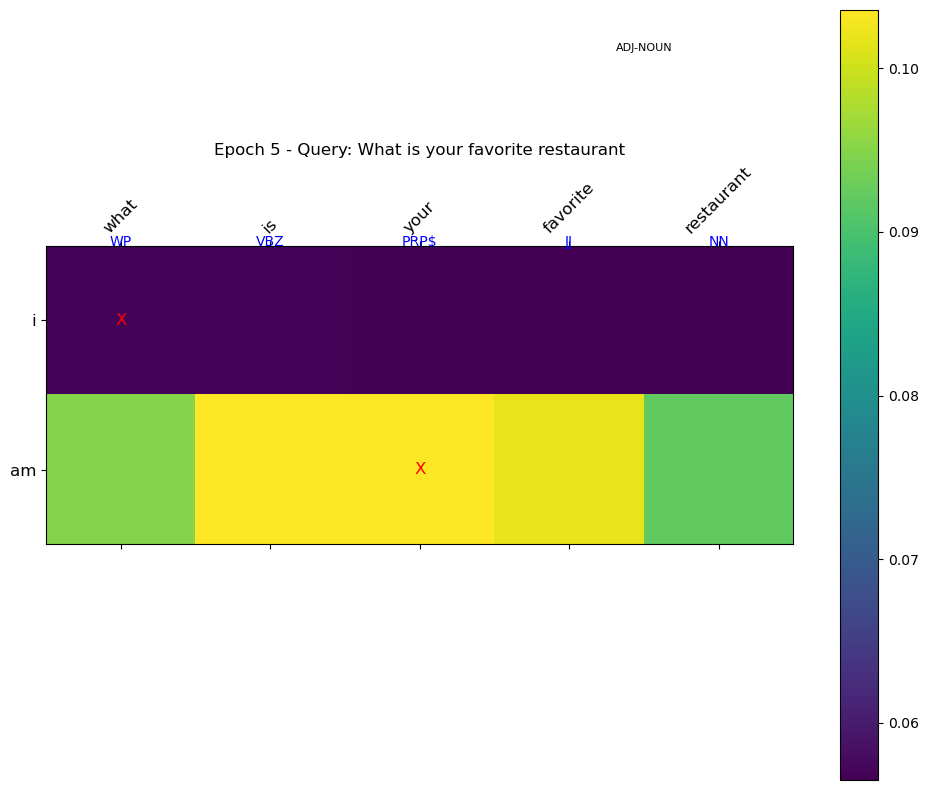


Query: Do you want to go out
Greedy: i am 
Beam-5: what 


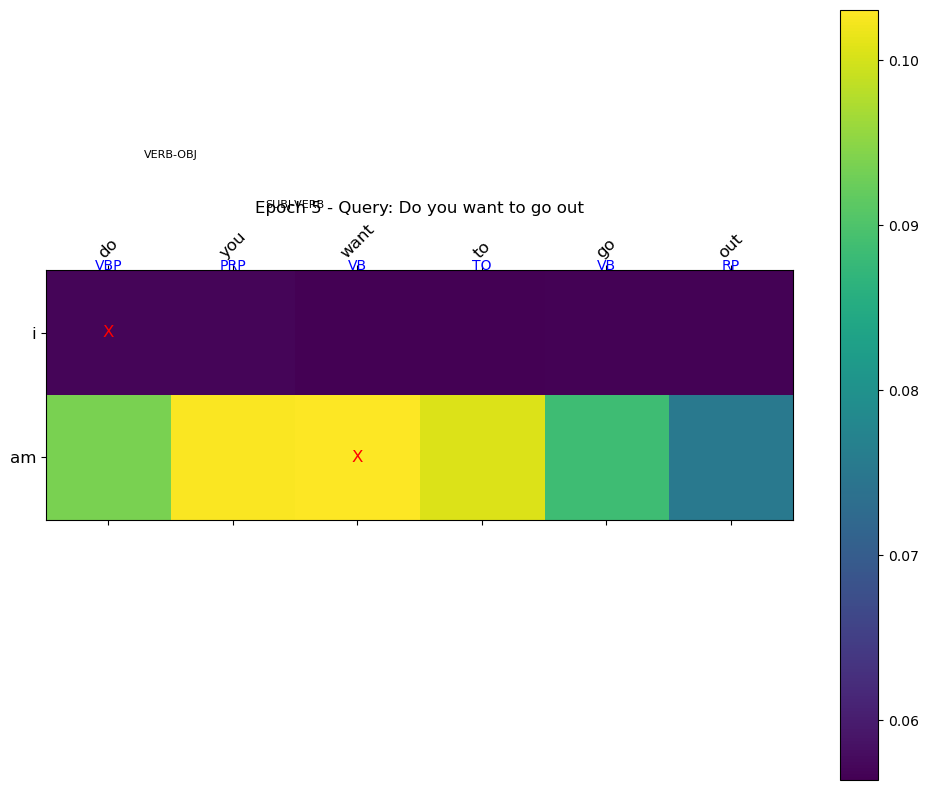


Query: Tell me about yourself
Greedy: i am 
Beam-5: what 


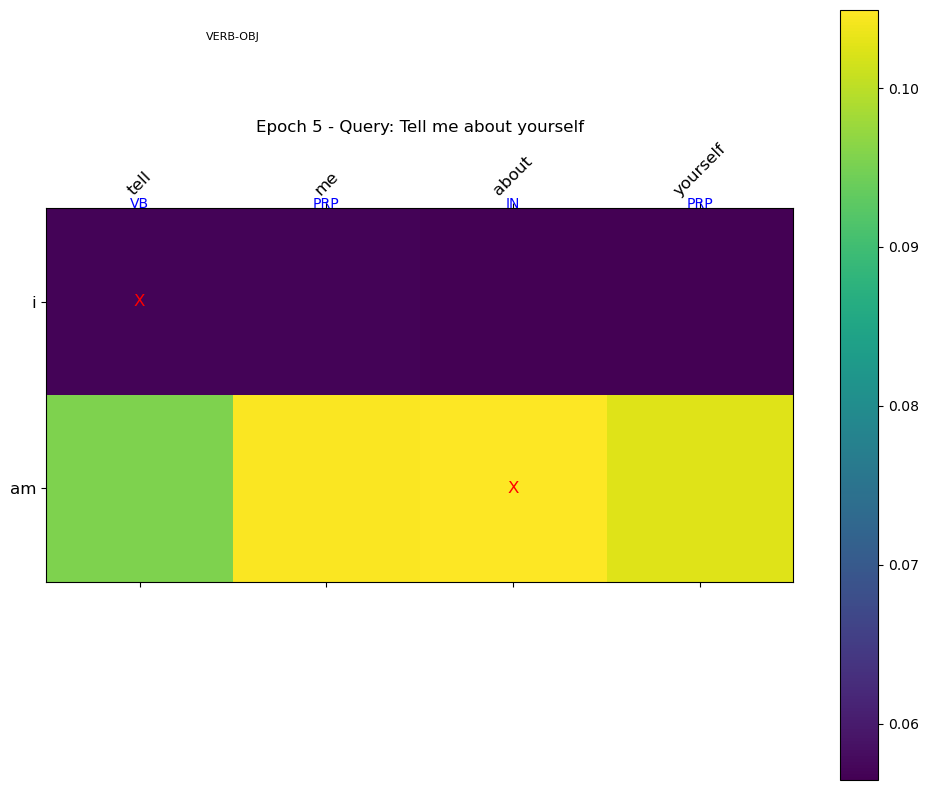


Query: Do you like movies
Greedy: i am 
Beam-5: what 


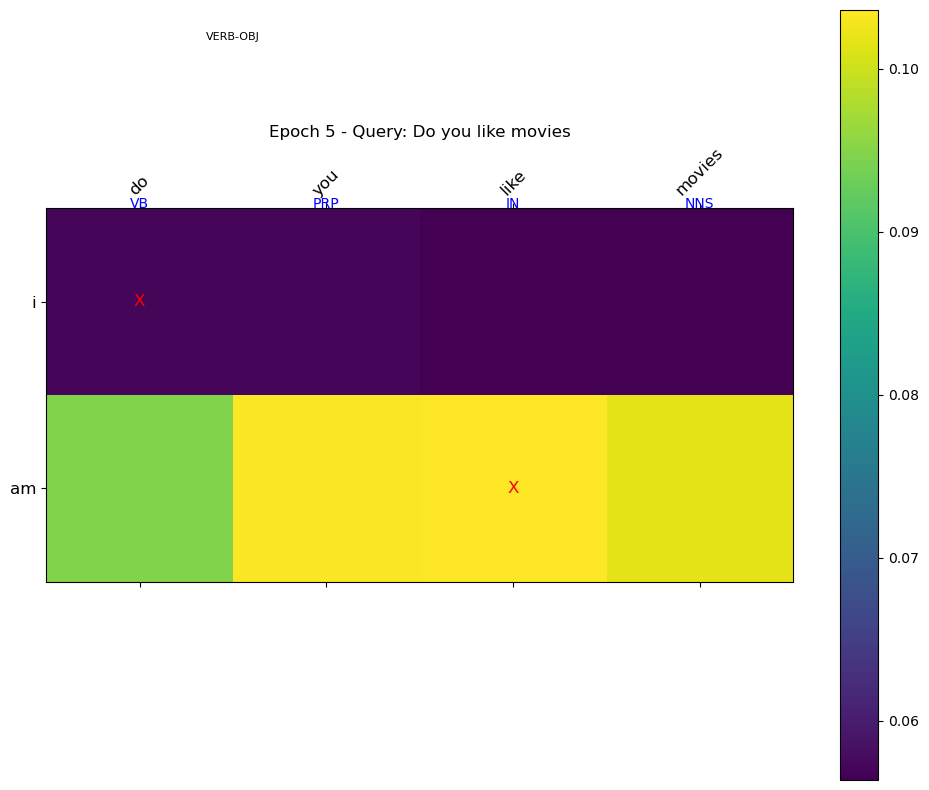


Query: What time is it
Greedy: i am 
Beam-5: what 


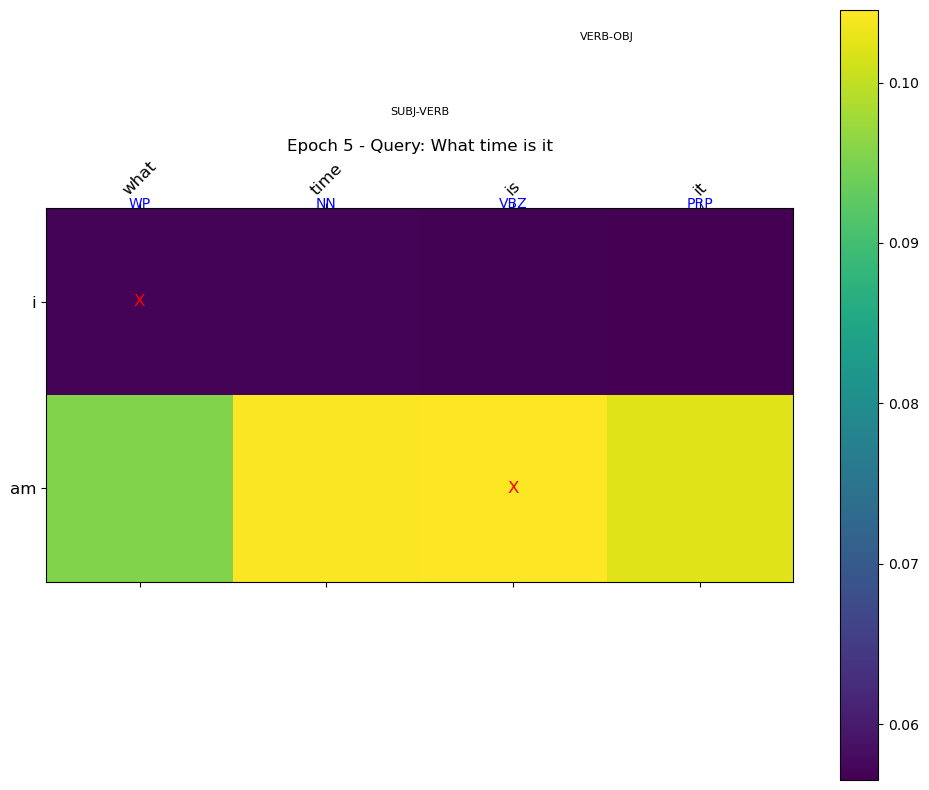


Query: Where are you from
Greedy: i am 
Beam-5: what 


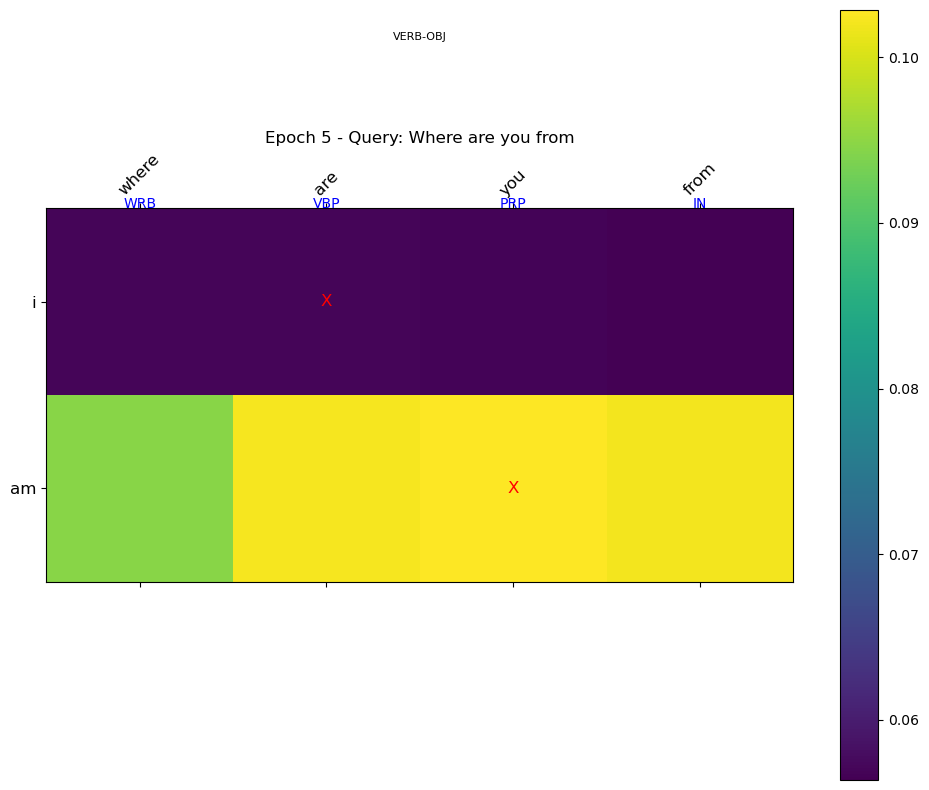


Query: Can you help me
Greedy: i am 
Beam-5: what 


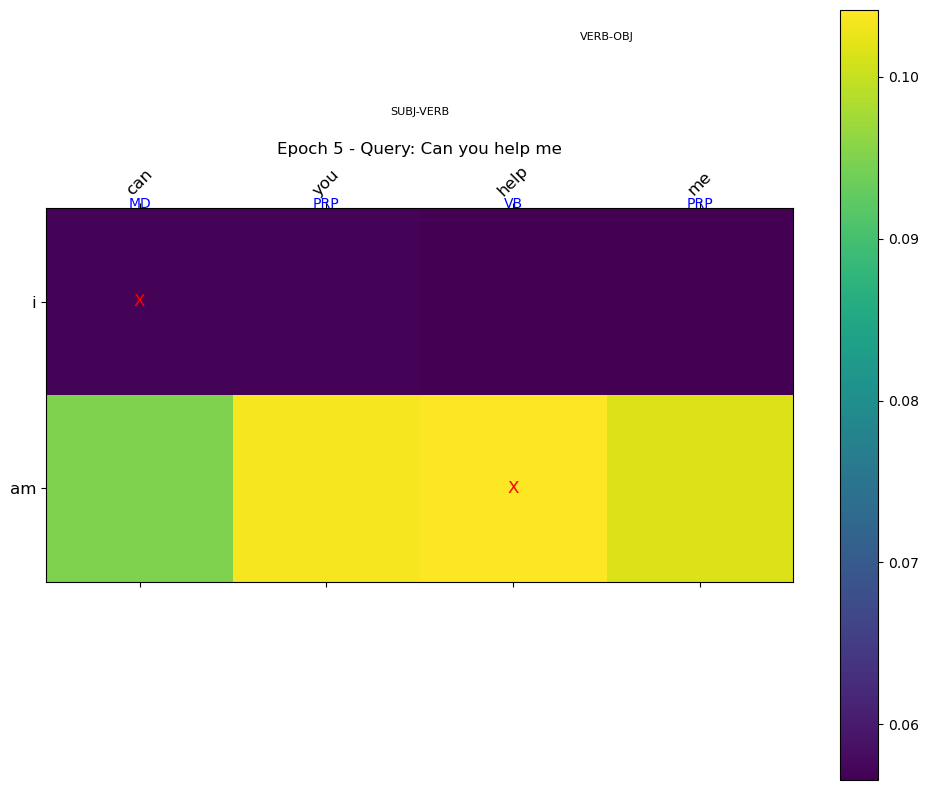


Summary for Epoch 5:
Greedy response lengths: Avg=2.0, Min=2, Max=2
Beam response lengths: Avg=1.0, Min=1, Max=1

Most common greedy responses:
  'i am ': 10 times

Most common beam responses:
  'what ': 10 times

Analyzing Epoch 51 Model


/tmp/ipykernel_154/642584176.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder = torch.load(f'encoder_{epoch}.pth')
/tmp/ipykernel_154/642584176.py:16: FutureWarn


Query: Hello
Greedy: hi 
Beam-5: you 


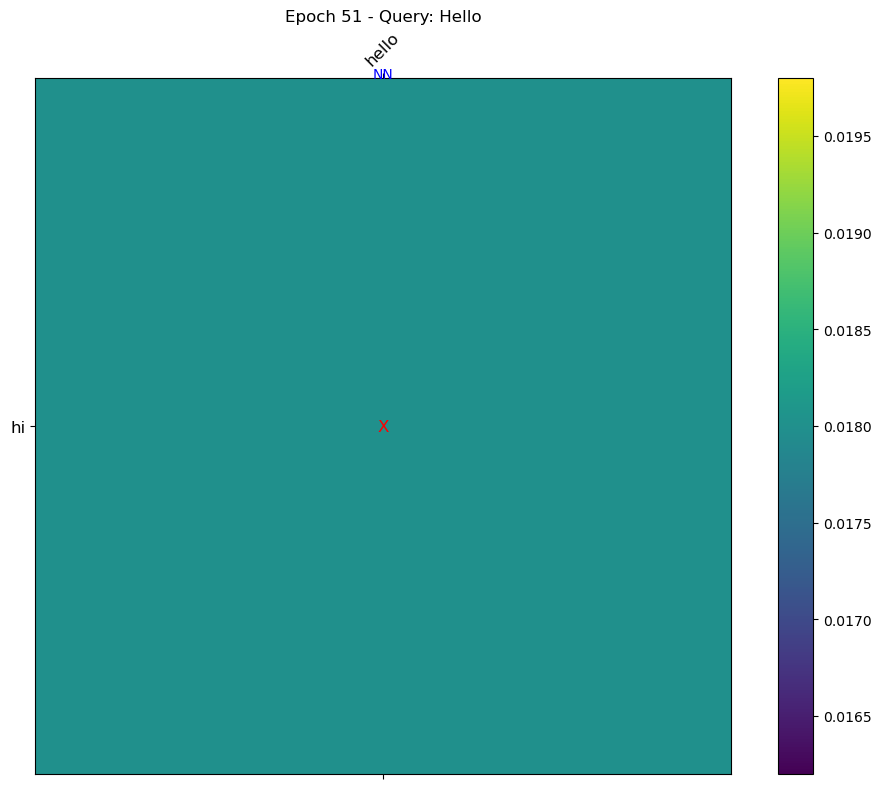


Query: How are you
Greedy: i am not 
Beam-5: that 


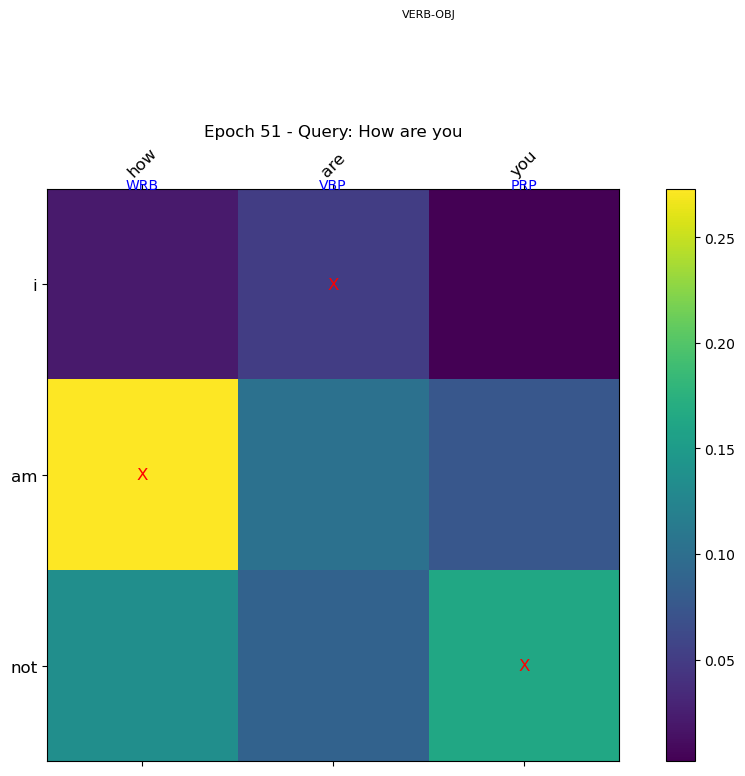


Query: What are you doing
Greedy: i am not 
Beam-5: that 


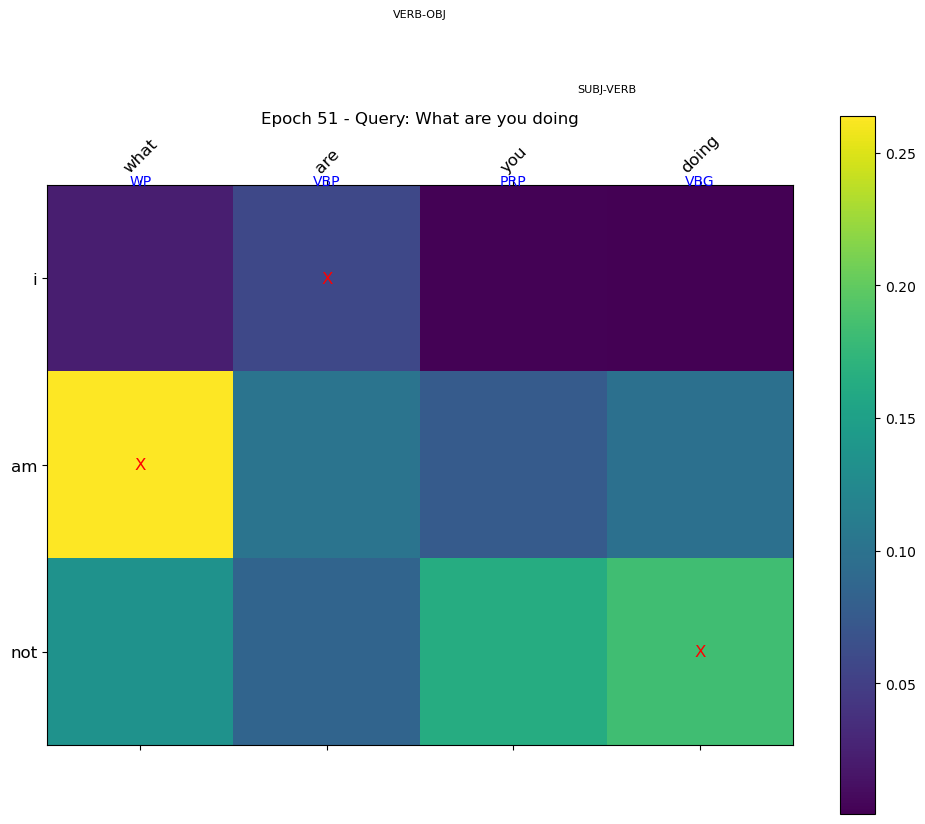


Query: What is your favorite restaurant
Greedy: i am not 
Beam-5: that 


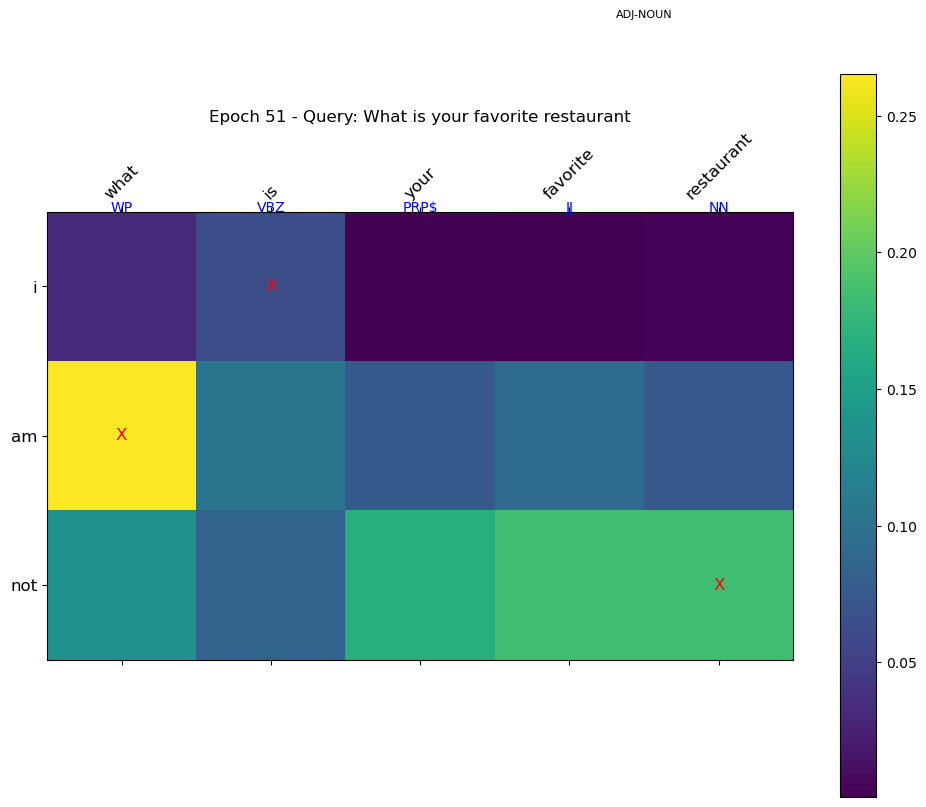


Query: Do you want to go out
Greedy: i am not 
Beam-5: that 


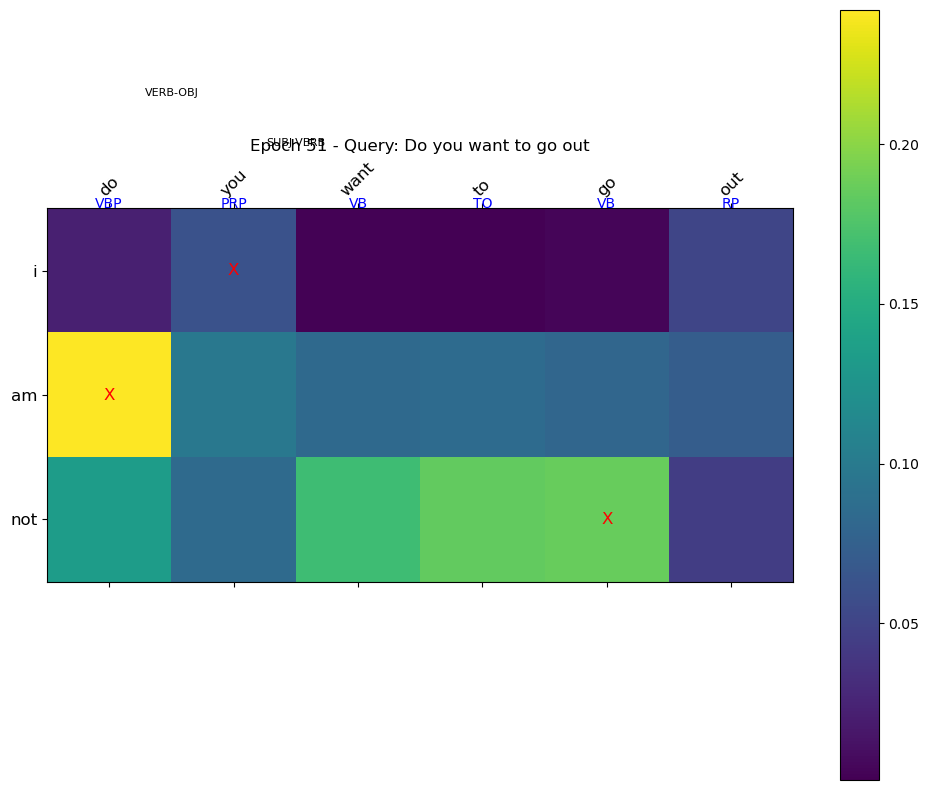


Query: Tell me about yourself
Greedy: i am not 
Beam-5: it 


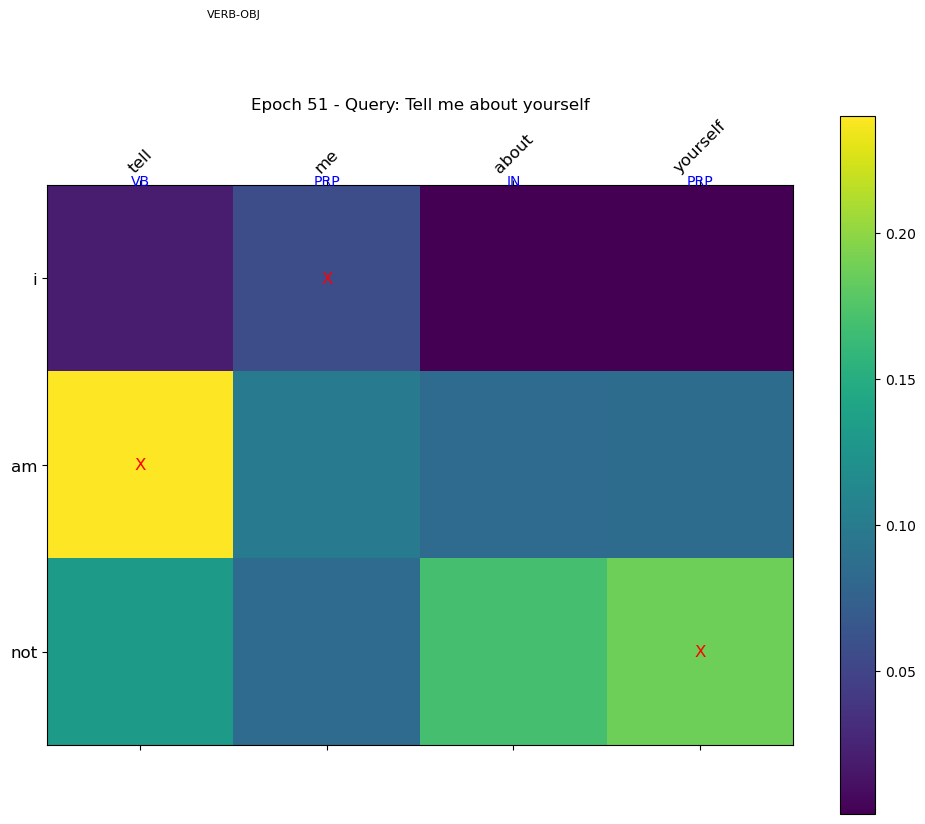


Query: Do you like movies
Greedy: i am not 
Beam-5: yes 


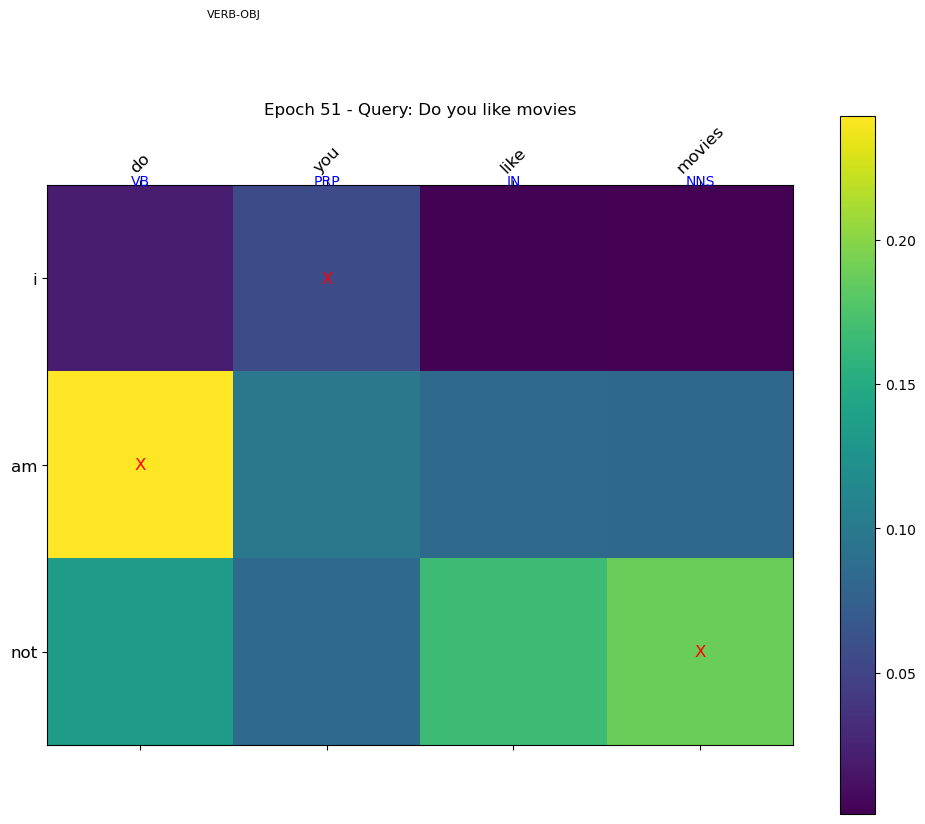


Query: What time is it
Greedy: i am not 
Beam-5: what 


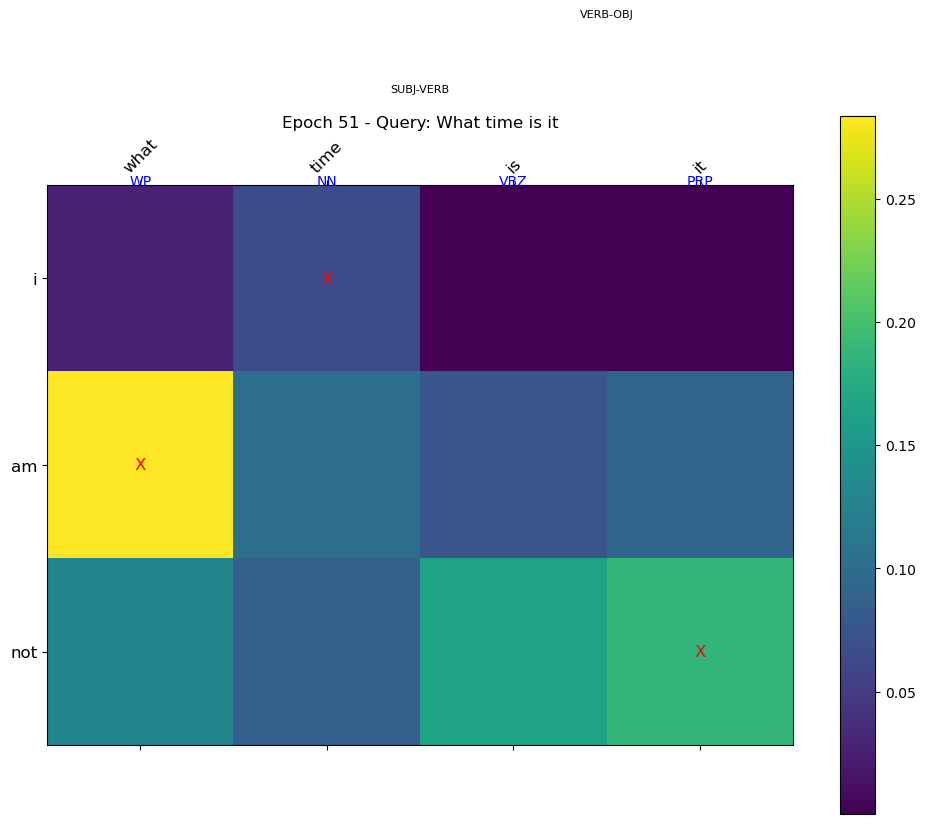


Query: Where are you from
Greedy: i am not 
Beam-5: the 


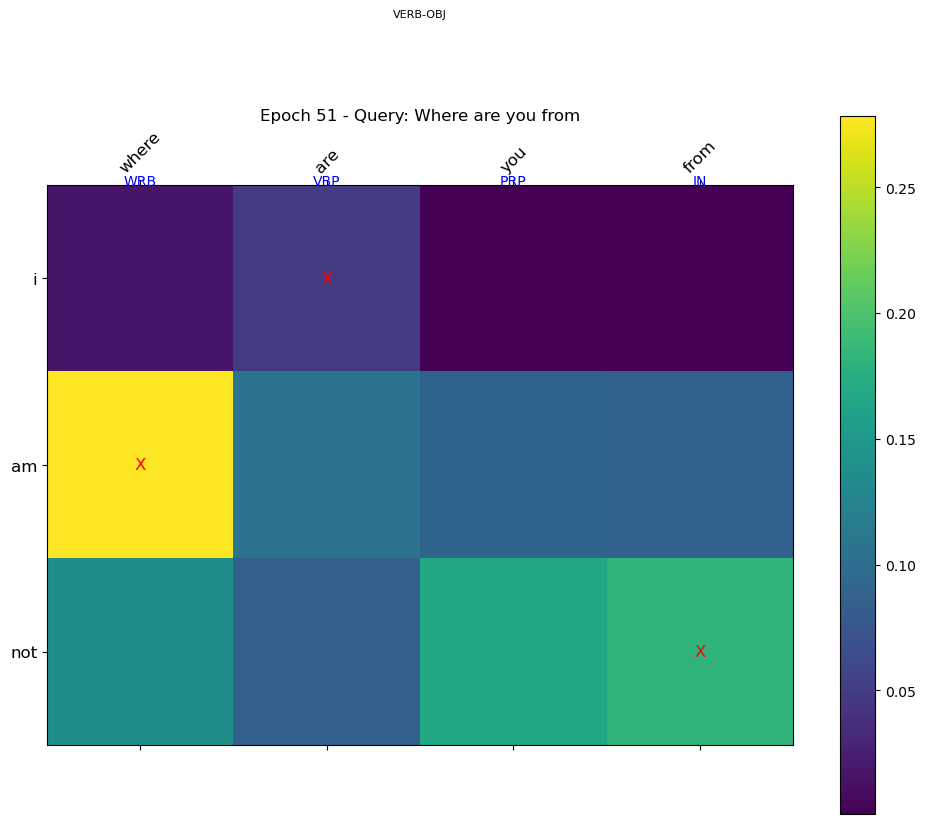


Query: Can you help me
Greedy: i am not 
Beam-5: yes 


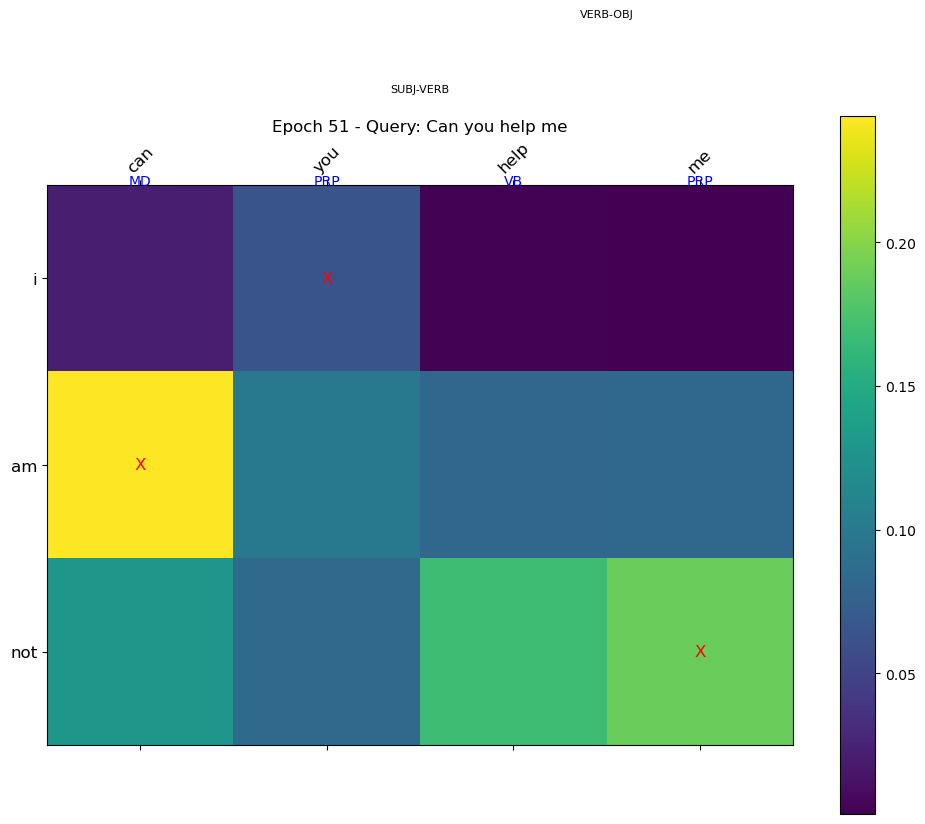


Summary for Epoch 51:
Greedy response lengths: Avg=2.8, Min=1, Max=3
Beam response lengths: Avg=1.0, Min=1, Max=1

Most common greedy responses:
  'i am not ': 9 times
  'hi ': 1 times

Most common beam responses:
  'that ': 4 times
  'yes ': 2 times

Analyzing Epoch 98 Model

Query: Hello


/tmp/ipykernel_154/642584176.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder = torch.load(f'encoder_{epoch}.pth')
/tmp/ipykernel_154/642584176.py:16: FutureWarn

Greedy: hi 
Beam-5: you 


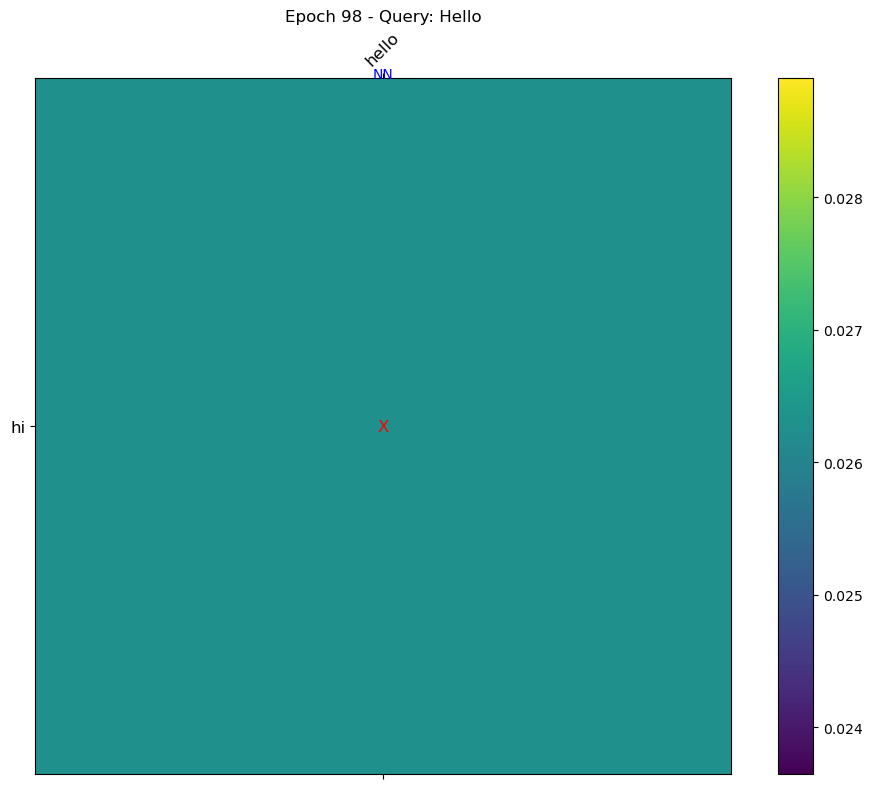


Query: How are you
Greedy: i am not going to do 
Beam-5: that 


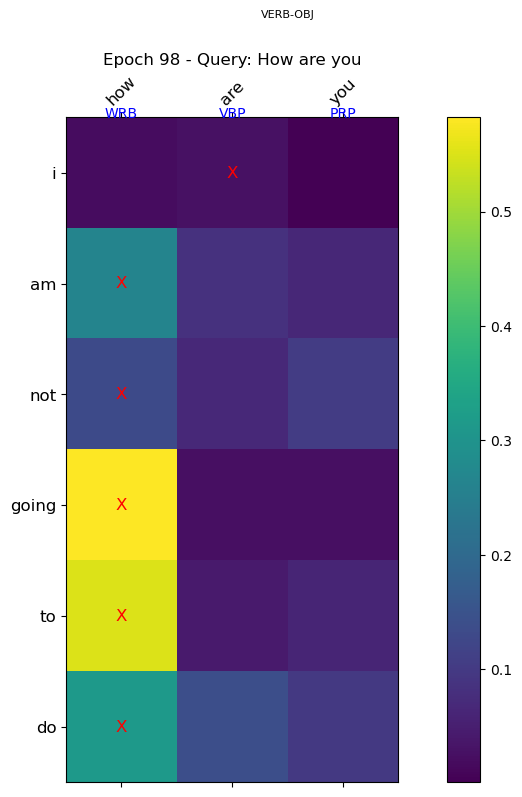


Query: What are you doing
Greedy: i am not going to do 
Beam-5: that 


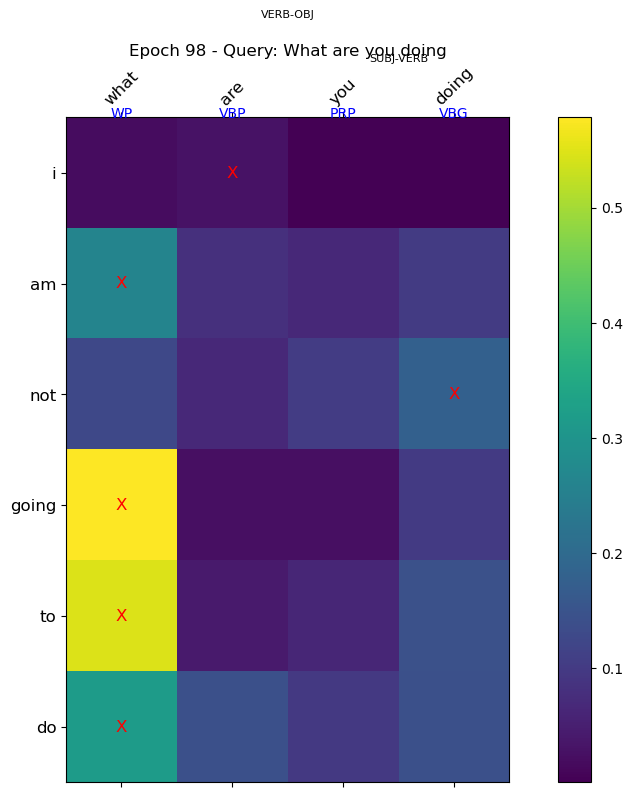


Query: What is your favorite restaurant
Greedy: i am not going to do 
Beam-5: that 


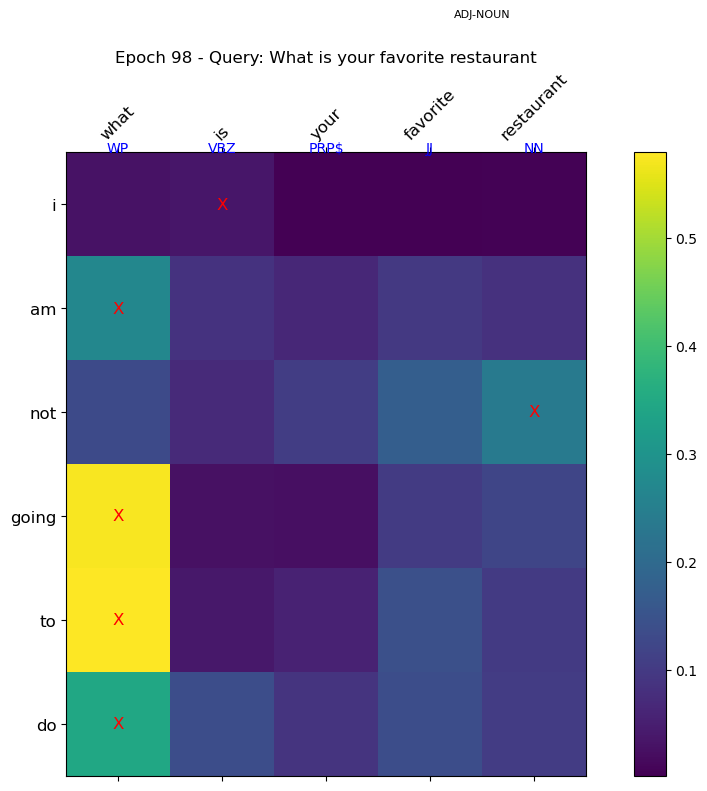


Query: Do you want to go out
Greedy: i am not going to do 
Beam-5: i i 


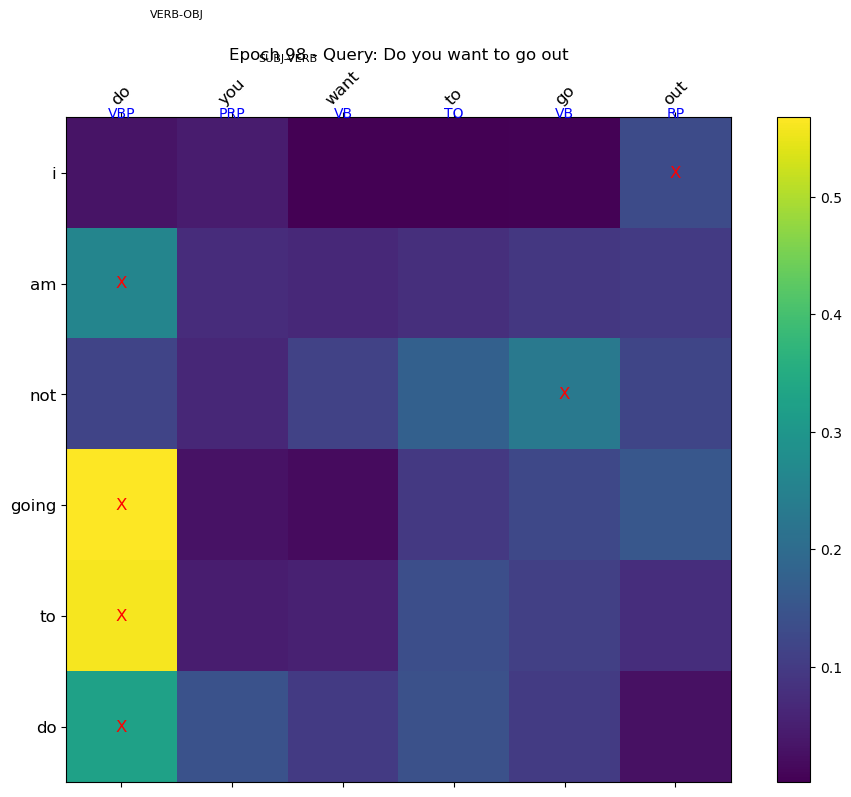


Query: Tell me about yourself
Greedy: i am not going to do 
Beam-5: that 


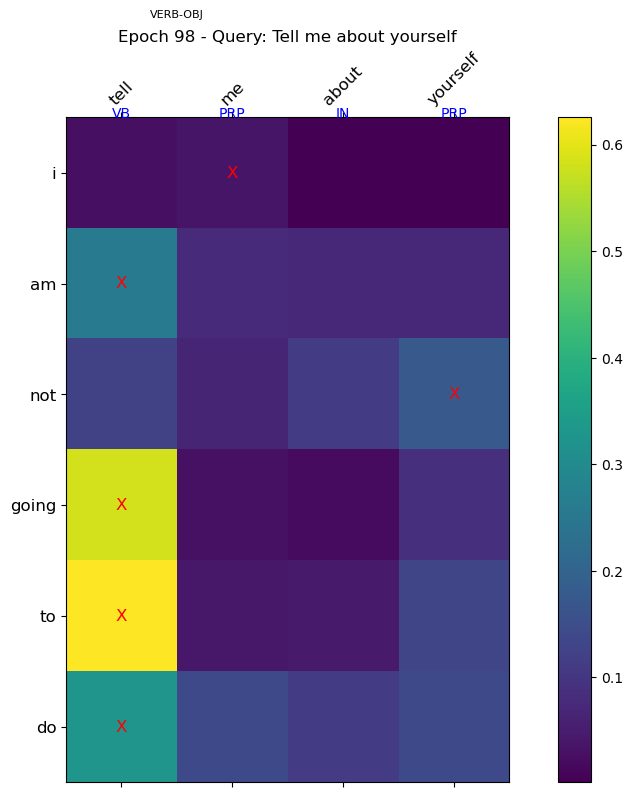


Query: Do you like movies
Greedy: i am not going to do 
Beam-5: yes 


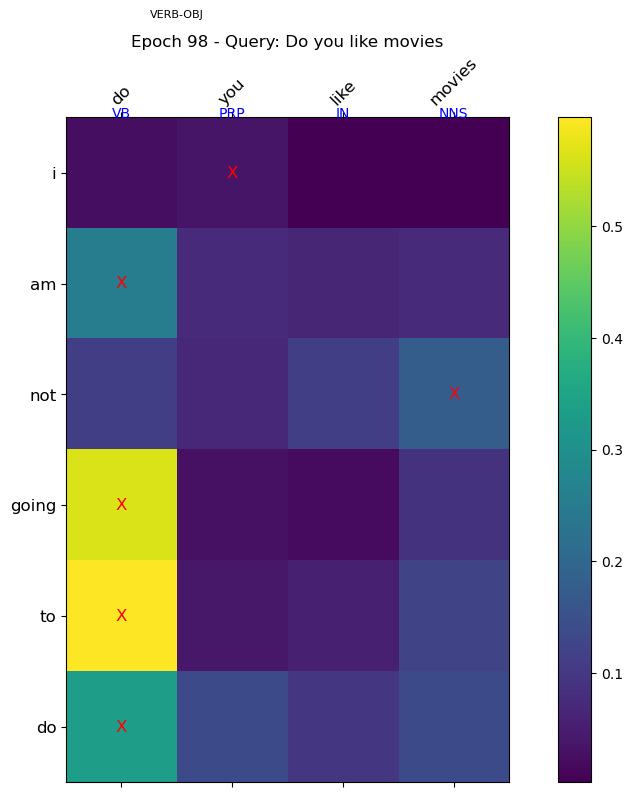


Query: What time is it
Greedy: i am not going to do 
Beam-5: the 


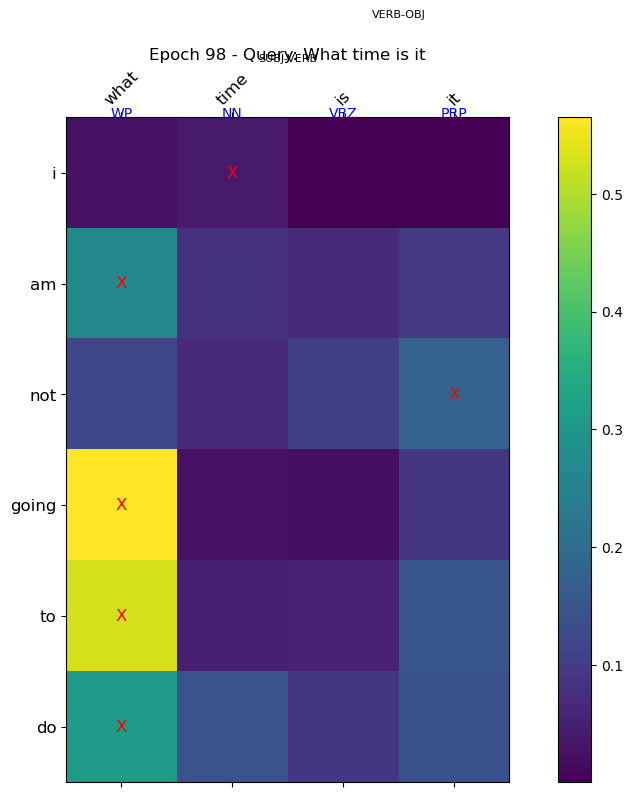


Query: Where are you from
Greedy: i am not going to do 
Beam-5: the 


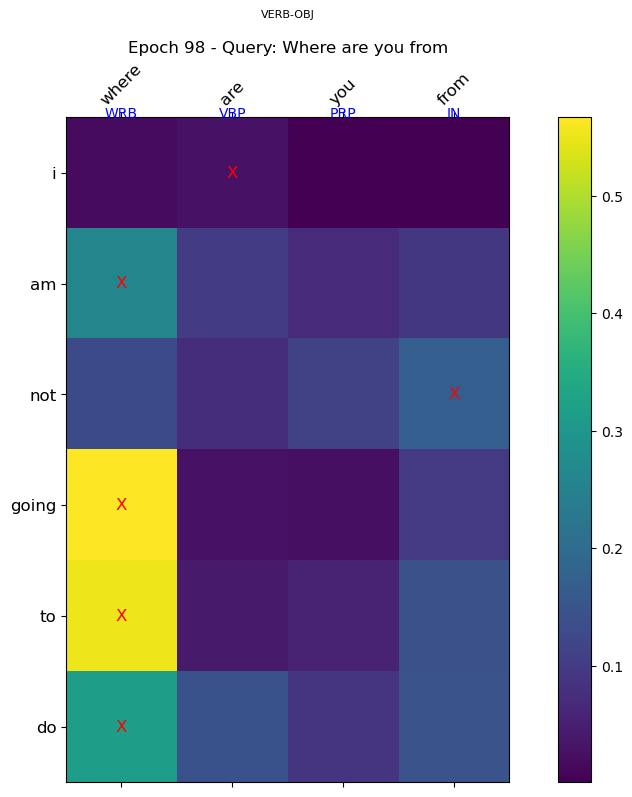


Query: Can you help me
Greedy: i am not going to do 
Beam-5: what 


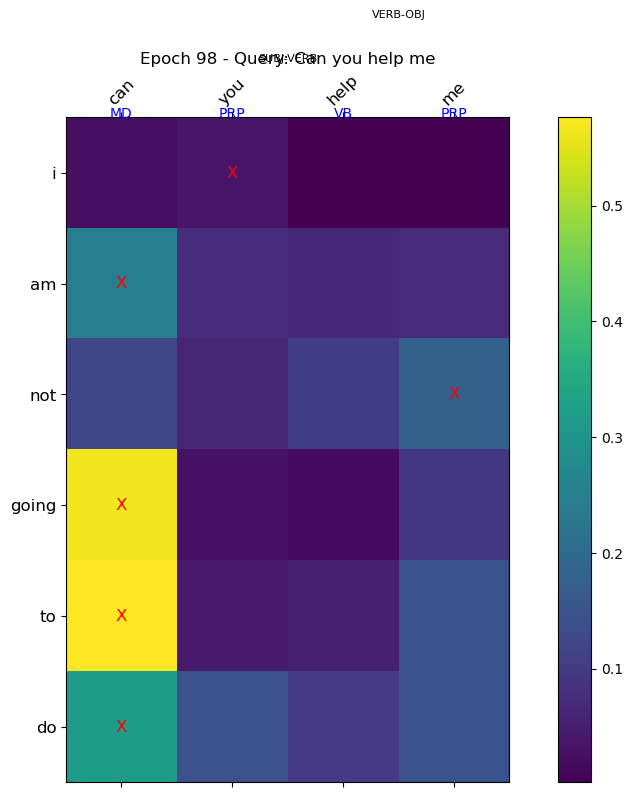


Summary for Epoch 98:
Greedy response lengths: Avg=5.5, Min=1, Max=6
Beam response lengths: Avg=1.1, Min=1, Max=2

Most common greedy responses:
  'i am not going to do ': 9 times
  'hi ': 1 times

Most common beam responses:
  'that ': 4 times
  'the ': 2 times

ANALYSIS OF RESPONSE LENGTHS
Epoch 5:
  Greedy: Avg=2.00, Min=2, Max=2
  Beam: Avg=1.00, Min=1, Max=1
Epoch 51:
  Greedy: Avg=2.80, Min=1, Max=3
  Beam: Avg=1.00, Min=1, Max=1
Epoch 98:
  Greedy: Avg=5.50, Min=1, Max=6
  Beam: Avg=1.10, Min=1, Max=2


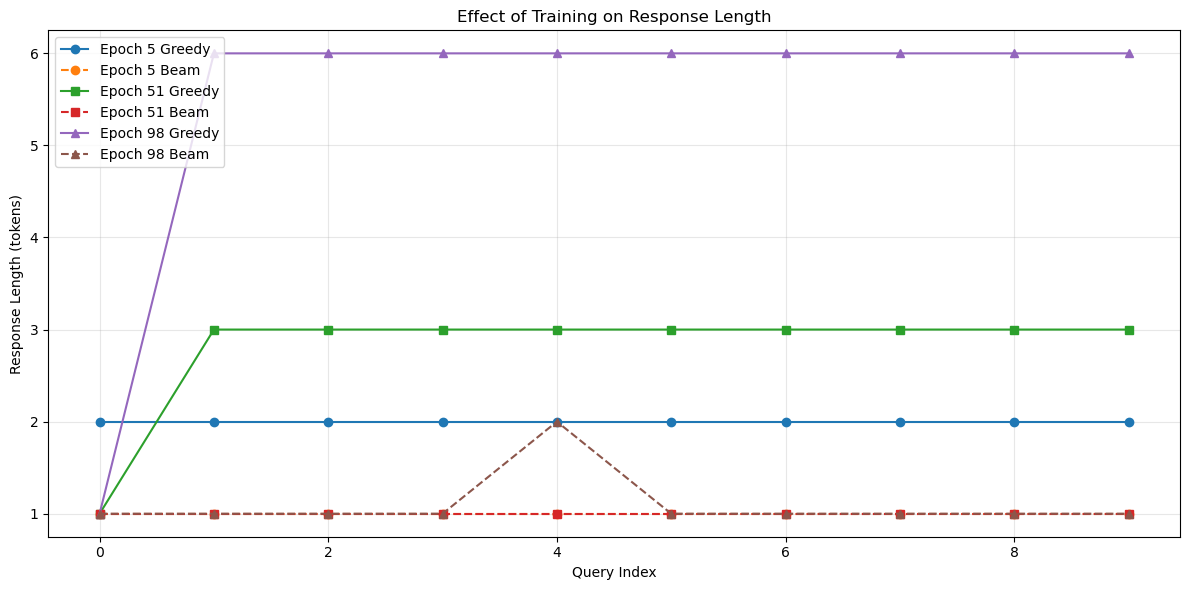


ANALYSIS OF ATTENTION TO RARE VS COMMON TOKENS

Epoch 5:
Medium words (3 tokens): Avg attention = 0.0775
  Highest attention examples:
    'favorite' (freq=85): 0.0792
    'movies' (freq=100): 0.0790
    'restaurant' (freq=44): 0.0744
Common words (36 tokens): Avg attention = 0.0784
  Highest attention examples:
    'hello' (freq=860): 0.0813
    'me' (freq=15681): 0.0808
    'about' (freq=6976): 0.0807

Epoch 51:
Medium words (3 tokens): Avg attention = 0.0902
  Highest attention examples:
    'favorite' (freq=85): 0.0926
    'movies' (freq=100): 0.0910
    'restaurant' (freq=44): 0.0870
Common words (36 tokens): Avg attention = 0.0956
  Highest attention examples:
    'what' (freq=21595): 0.1469
    'where' (freq=4624): 0.1444
    'what' (freq=21595): 0.1442

Epoch 98:
Medium words (3 tokens): Avg attention = 0.1062
  Highest attention examples:
    'favorite' (freq=85): 0.1091
    'restaurant' (freq=44): 0.1083
    'movies' (freq=100): 0.1013
Common words (36 tokens): Avg attention

In [65]:
#analysis run
# can replace the numbers with path nums
results = task3_analysis(epochs_to_analyze=[5, 51, 98])